In [ ]:
# QUIMB for tensor formation from exact wavefunction

import numpy as np
import quimb.tensor as qtn

import numpy as np
import quimb.tensor as qtn
from openfermion import QubitOperator

PAULI = {
    "I": np.eye(2, dtype=complex),
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}

def qubit_operator_to_mpo(H: QubitOperator, n_qubits=None, cutoff=1e-12):
    # infer system size
    if n_qubits is None:
        n_qubits = 1 + max(
            (i for term in H.terms for i, _ in term),
            default=-1,
        )

    mpo = None

    for term, coeff in H.terms.items():
        # term is like ((0, 'X'), (3, 'Z'))
        ops = [PAULI["I"] for _ in range(n_qubits)]

        for i, p in term:
            ops[i] = PAULI[p]

        # absorb coefficient into one site
        ops[0] = coeff * ops[0]

        term_mpo = qtn.MPO_product_operator(ops)

        if mpo is None:
            mpo = term_mpo
        else:
            mpo = mpo.add_MPO(term_mpo, inplace=False)

            # optional compression after each addition
            #mpo.compress(cutoff=cutoff, cutoff_mode="rel")

    return mpo

#mpo = qubit_operator_to_mpo(HQ, n_qubits, 1e-5)


# psi = np.random.randn(2**10) + 1j * np.random.randn(2**10)
# psi /= np.linalg.norm(psi)

psi = gs#get_ground_state(get_sparse_operator(H_perm_, n_qubits))[1]

mps = qtn.MatrixProductState.from_dense(
    psi,
    dims=2,
    cutoff=1e-12,      # truncation threshold
    cutoff_mode='rel' # optional, this is the default in tensor_split
    # max_bond=None    # implicit default
)

print(mps.bond_sizes())


# TODO:
# iQCC - MPS, MPO construction
# Restrict to Cliffords and test


psi_mps = mps.to_dense().reshape(-1)
psi0 = psi.reshape(-1)

state_err = np.linalg.norm(psi0 - psi_mps)
fidelity = abs(np.vdot(psi0, psi_mps))**2

print(state_err, fidelity)

[2, 4, 8, 16, 22, 19, 29, 29, 23, 16, 8, 4, 2]
6.038619897882554e-13 1.000000000000004


In [ ]:
# BO energies

h2o_bo_e = get_BO_energies(HQ, sym_bs, n_qubits)
min(h2o_bo_e)

# -74.720 # sen
# -74.742 # hct N/2
# -74.726 # bs N/2

-74.72606055846724

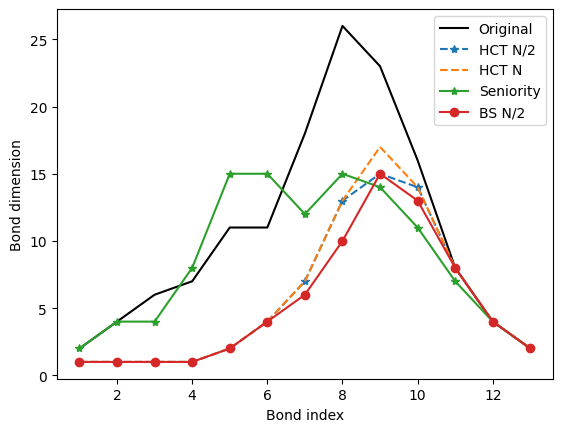

In [ ]:
#DATA h2o 2.1 10^-5 rel truncation, minimize |<cisd| [H, S]^2 |cisd>|
og_bd = [2, 4, 6, 7, 11, 11, 18, 26, 23, 16, 8, 4, 2]
hct_bd =  [1, 1, 1, 1, 2, 4, 7, 13, 15, 14, 8, 4, 2]
hct_bd_N = [1, 1, 1, 1, 2, 4, 7, 13, 17, 14, 8, 4, 2]
sen_bd = [2, 4, 4, 8, 15, 15, 12, 15, 14, 11, 7, 4, 2]
bs_bd = [1, 1, 1, 1, 2, 4, 6, 10, 15, 13, 8, 4, 2]

import matplotlib.pyplot as plt

plt.plot(range(1, len(og_bd)+1), og_bd, color='black',label="Original")
plt.plot(range(1, len(og_bd)+1), hct_bd, '*--', label="HCT N/2")
plt.plot(range(1, len(og_bd)+1), hct_bd_N, '--', label="HCT N")
plt.plot(range(1, len(og_bd)+1), sen_bd, '*-', label="Seniority")
plt.plot(range(1, len(bs_bd)+1), bs_bd, 'o-', label="BS N/2")
plt.legend()
plt.xlabel("Bond index")
plt.ylabel("Bond dimension")
plt.savefig('./saved/mps_bd_H2O2.1.png')

In [8]:
sym_sen = get_seniority_symmetries(n_qubits)
from src.metrics import get_ent
sen_ent, H_perm_sen, gs_sen = get_ent(sym_sen, HQ, n_qubits, verbose=True, return_state=True)



Symmetries rotated to Z on qubits:  [0, 2, 4, 6, 8, 10, 12]
Qubits permuted as:
0 -> 0
1 -> 7
2 -> 1
3 -> 8
4 -> 2
5 -> 9
6 -> 3
7 -> 10
8 -> 4
9 -> 11
10 -> 5
11 -> 12
12 -> 6
13 -> 13
Entropy of cuts (bits):
1 | 2 : 5.234350403326139e-07
2 | 3 : 0.020185722954753946
3 | 4 : 0.020185722954753887
4 | 5 : 0.7691185459960802
5 | 6 : 0.7798151111726477
6 | 7 : 0.7749619493423159
7 | 8 : 0.7632535296656728
8 | 9 : 0.7632535403431155
9 | 10 : 0.7667094888964353
10 | 11 : 0.7680429241588311
11 | 12 : 1.637989473754995
12 | 13 : 1.830628480312806
13 | 14 : 0.91035197713856


In [12]:
from openfermion import QubitOperator
from copy import deepcopy
from pyblock2.driver.core import DMRGDriver, SymmetryTypes
from src.tn import QO_to_block2_MPO

driver = DMRGDriver(
    scratch="./tmp_block2_pauli",
    symm_type=SymmetryTypes.SGB,
    n_threads=4,
)

# In Pauli mode, only n_sites is required.
driver.initialize_system(n_sites=n_qubits, pauli_mode=True)
mpo = QO_to_block2_MPO(H_perm_sen, n_qubits)

n_sweeps =32
bd=20

for r in range(30):
    ket = driver.get_random_mps(tag="KET", bond_dim=bd, nroots=1) #nroots corresponds to number of MPS >1 for excited states
    energy = driver.dmrg(
        mpo,
        ket,
        n_sweeps=n_sweeps,
        bond_dims=None,
        noises= [1e-3]*4 + [1e-4]*4 + [1e-5]*4 + [1e-6]*4 + [0.0]*8,
        thrds= [1e-8, 1e-9] + [1e-10] * (n_sweeps-2),
        dav_max_iter=50,
        iprint=0,
    )

    print(abs(e - np.array(energy)))


0.010045347502654067
0.010045346712217906
0.010045350160126532
0.010045348396133136
0.01004534912743793
0.010045346847974201
0.010045348503638252
0.0100453485982257
0.010045349177389085
0.010045347903655966
0.010045348966841061
0.010045346784821163
0.010045353546189517
0.010045348622128358
0.010045349865535513
0.01004535134606499
0.01004534884310715
0.010045348687640399
0.0249609826078796
0.010045348924464292
0.010045348581854796
0.024960982511686325
0.010045348578742619
0.010045345852887522
0.01004534858026318
0.02496098236679245
0.010045348661591902
0.013035815746633261
0.010045348636552376
0.010045348523604503


In [1]:
### sample code to test HCT and beam search

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator
from src.state_utils import get_cisd_gs, get_fci_state_openfermion
from src.op_utils import build_H_chain_for_R, h2o_geometry
from src.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod

from src.bs.utils import *
from src.bs.beam import *

# hct
from src.metrics import variance, comm_sq_exp_fast, find_commuting_paulis, universal_grading
from src.state_utils import get_hf_occ, get_hf_wfn

bl = 1.6
geometry = [
    ('Li', (0.0, 0.0, -bl/2)),
    ('H', (0.0, 0.0, bl/2))
]

# bl = 2.0
# geometry = [
#     ('N', (0.0, 0.0, -bl/2)),
#     ('N', (0.0, 0.0, bl/2))
# ]

geometry = h2o_geometry(2.1, 104.5) 

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=True
)

n_H = 4
H, molecule =  build_H_chain_for_R(1.0, n_H)

# Get second-quantized electronic Hamiltonian and wavefunctions
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)

e, gs, gs_info = get_fci_state_openfermion(molecule)
gs = gs.toarray()

hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals, as_str=True)
cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')

#pick your favorite metric functions (to lower):
comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_wfn, n_qubits)
comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, gs, n_qubits)
var_cisd = lambda s_list: variance(s_list, cisd_wfn, n_qubits)
var_fci = lambda s_list: variance(s_list, gs, n_qubits)

sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized

n_sym = n_qubits//2
sym_hct, eps = hct_mod(HQ, n_sym, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
sym_sen = get_seniority_symmetries(n_qubits)
sym_quar = get_quartic_symmetries(n_qubits)

print("\nBeam Search with exact-symmetry seeding:")
sym_bs = find_commuting_symmetry_generators(
    HQ,
    target_rank=n_sym,
    beam_width=16,
    heavy_core_fraction=0.95,
    include_pairwise_products=True,
    pairwise_seed_terms=12,
    seed_with_exact_symmetries=True,
    score_func= sym_group_score_func # this function maximizes the cost function TODO invert this
)
for s in sym_bs:
    print("  ", s)

assert False
# evaluate metrics
from src.metrics import universal_grading, entropy_pauli_syms, find_commuting_paulis, get_ent

print("Non-commutativity")
print("HCT:{}".format(universal_grading(sym_hct, HQ)))
print("Seniority:{}".format(universal_grading(sym_sen, HQ)))
print("Quartic:{}".format(universal_grading(sym_quar, HQ)))
print("BS:{}".format(universal_grading(sym_bs, HQ)))

print("Entropies:")
print("HCT: ", entropy_pauli_syms(sym_hct, gs, n_qubits))
print("Seniority: ", entropy_pauli_syms(sym_sen, gs, n_qubits))
print("Quartic: ", entropy_pauli_syms(sym_quar, gs, n_qubits))
print("BS: ", entropy_pauli_syms(sym_bs, gs, n_qubits))

print("HCT, SEN, QUARTIC, BS (non commuting terms)")
_ = find_commuting_paulis(HQ, sym_hct)
_ = find_commuting_paulis(HQ, sym_sen)
_ = find_commuting_paulis(HQ, sym_quar)
_ = find_commuting_paulis(HQ, sym_bs)

from src.tn import find_dmrg_conv_bd
from src.metrics import get_BO_energies

print("Minimum single sector energies:")
h2o_bo_e_hct = get_BO_energies(HQ, sym_hct, n_qubits)
print("HCT: ", min(h2o_bo_e_hct))

h2o_bo_e_sen = get_BO_energies(HQ, sym_sen, n_qubits)
print("Sen: ", min(h2o_bo_e_sen))

h2o_bo_e_bs = get_BO_energies(HQ, sym_bs, n_qubits)
print("BS: ", min(h2o_bo_e_bs))

best_bs_hct, tree = bs_hct(HQ, n_sym=n_sym, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
sym_bs_hct = best_bs_hct.syms
bs_hct_e = get_BO_energies(HQ, sym_bs_hct, n_qubits)
print("BS HCT: ", min(bs_hct_e))
bs_hct_ent, H_perm_bs_hct, gs_bs_hct = get_ent(sym_bs_hct, HQ, n_qubits, verbose=True, return_state=True)
bs_hct_bd = find_dmrg_conv_bd(H_perm_bs_hct, n_qubits, e, 20, n_sweeps=50, reps=20)
print("DMRG bd for convergence for BS-HCT: ", bs_hct_bd)


# max_bd=20
# og_bd = find_dmrg_conv_bd(HQ, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence for original Hamiltonian: ", og_bd)

# # bi-partite entanglement
# print("Sen")
# sen_ent, H_perm_sen, gs_sen = get_ent(sym_sen, HQ, n_qubits, verbose=True, return_state=True)
# sen_bd = find_dmrg_conv_bd(H_perm_sen, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence: ", sen_bd)

# print("HCT N/2 syms")
# hct_ent, H_perm_hct, gs_hct = get_ent(sym_hct, HQ, n_qubits, verbose=True, return_state=True)
# hct_bd = find_dmrg_conv_bd(H_perm_hct, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence: ", hct_bd)

# print("BS N/2 syms")
# bs_ent, H_perm_bs, gs_bs = get_ent(sym_bs, HQ, n_qubits, verbose=True, return_state=True)
# bs_bd = find_dmrg_conv_bd(H_perm_bs, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=10)
# print("DMRG bd for convergence: ", bs_bd)

/Users/praveenjayakumar/Jay Family Dropbox/praveen jayakumar/6.To-Fro Praveen/UToronto/codes backup/seniority/QuasiSymmetries/src/state_utils.py:405: ComplexWarning: Casting complex values to real discards the imaginary part
  wfs[iindx] = gs[iidx]


1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.02616133069920393 with metric value  0.0009667622051704246

Beam Search with exact-symmetry seeding:
   1.0 [Z0 Z3 Z4 Z7]
   1.0 [Z1 Z3 Z5 Z7]
   1.0 [Z2 Z3 Z6 Z7]
   1.0 [Z0 Z1 Z6 Z7]


AssertionError: 

1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.0343664981694758 with metric value  0.0008034660518486471
1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.0343664981694758 with metric value  0.0008034660518486471
1.0 [Z0 Z3 Z6 Z7]  added at threshold 0.037060909590136235 with metric value  0.29111862354777873
1.0 [Z0 Z3]  added at threshold 0.0392231447304135 with metric value  0.3264835112087733
1.0 [Z0]  added at threshold 0.04011593093922328 with metric value  0.15004021131329093
1.0 [Z7]  added at threshold 0.05883261136363438 with metric value  0.14573820783064892
At threshold e: 0.0343664981694758, 2 new direction

AssertionError: 

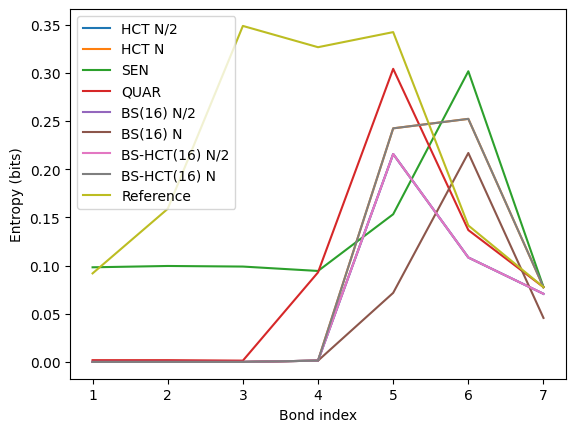

In [ ]:
from __future__ import annotations
# benchmark scripts

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
import pickle

from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator, QubitOperator
from src.state_utils import get_cisd_gs, get_fci_state_openfermion
from src.op_utils import build_H_chain_for_R, h2o_geometry
from src.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod, bs_hct

from src.bs.utils import *
from src.bs.beam import *

# hct
from src.state_utils import get_hf_occ, get_hf_wfn

from src.metrics import *
from src.tn import find_dmrg_conv_bd
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import pandas as pd

@dataclass
class BenchmarkData:
    tag: str = ''
    symmetries: list[QubitOperator] = field(default_factory=list)
    non_commuting_l1: float = 0
    num_commuting_terms: int = 0
    sym_entropy: float = 0
    cut_entropies: list[float] = field(default_factory=list)
    dmrg_bd: int = 0
    single_sector_e: float = 0

    def write_to_file(self, filename):
        ent_str = "\n".join([val.__str__() for val in self.cut_entropies])
        with open(filename, 'a') as f:
            print(self.tag, file=f)
            print("Symmetries:", file=f)
            print("\n".join([sym.__str__() for sym in self.symmetries]), file=f)
            print("Non-commutator L1: ", self.non_commuting_l1, file=f)
            print("Entropy: ", self.sym_entropy, file=f)
            print("Commuting terms: ", self.num_commuting_terms, file=f)
            print("Cut entropies:\n", ent_str, file=f)
            print("DMRG conv BD: ", self.dmrg_bd, file=f)
            print("Single sector energy: ", self.single_sector_e, file=f)
    
    def save(self, filename):
        """
        Save as pickle object

        """
        with open(filename, 'wb') as f:
            pickle.dump(self, file=f)
    
    @classmethod
    def save_datasets(cls, datasets: list[BenchmarkData], filename):
        """
        Save datasets into single file as a dictionary

        """
        datasets = {}
        for data in datasets:
            datasets[data.tag] = data
        
        with open(filename + '.pkl', 'wb') as f:
            pickle.dump(datasets, file=f)

    @classmethod
    def plot_cut_entropies(cls, datasets: list[BenchmarkData], gs=None, filename: str = None):
        """
        Save and return plot for entropies.
        """
        fig, ax = plt.subplots()

        for data in datasets:
            n_qubits = len(data.cut_entropies) + 1
            x = range(1, n_qubits)
            ax.plot(x, data.cut_entropies, label=data.tag)
        
        if gs is not None:
            #reference state
            n_qubits = int(np.log2(len(gs)))
            gs_ent = get_entropies_at_cuts(gs, n_qubits)
            x = range(1, n_qubits)
            ax.plot(x, gs_ent, label="Reference")

        ax.legend()
        ax.set_xlabel("Bond index")
        ax.set_ylabel("Entropy (bits)")

        if filename is not None: fig.savefig(filename, dpi=300, bbox_inches="tight")

        return fig

def benchmark_syms(list_syms, HQ, fci, fci_e, n_qubits, N_2_sym=False, verbose=True, print_to_file=None, tag=""):
    """
    Run all benchmarks for symmetries

    """
    print(tag)
    nc_l1 = universal_grading(list_syms, HQ, verbose=verbose)
    c = len(find_commuting_paulis(HQ, list_syms, verbose=verbose))
    ent, H_perm, gs_rot = get_ent(list_syms, HQ, n_qubits, verbose=verbose, return_state=True)
    dmrg_bd = find_dmrg_conv_bd(H_perm, n_qubits, fci_e, max_bd=30, tol=1.6e-3, n_sweeps=50, reps=20, verbose=verbose)    

    #ent and dmrg
    if N_2_sym:
        ent_N_2 = entropy_pauli_syms(list_syms, fci, n_qubits, verbose=verbose)
        ss_energies = get_single_sector_energies(HQ, list_syms, n_qubits, verbose=verbose)
        ss_e = np.min(ss_energies)
        #N/2 syms, single sector, BO energies TODO K and BO energies, but they are not really relevant here

        data = BenchmarkData(tag=tag, symmetries=list_syms, non_commuting_l1 = nc_l1, num_commuting_terms=c,  sym_entropy=ent_N_2, cut_entropies=ent, dmrg_bd=dmrg_bd, single_sector_e=ss_e)
    else:
        data = BenchmarkData(tag=tag, symmetries=list_syms, non_commuting_l1 = nc_l1, num_commuting_terms=c, cut_entropies=ent, dmrg_bd=dmrg_bd)
    
    if print_to_file is not None:
        data.write_to_file(print_to_file)

    return data

directory = "./saved/hamiltonians/"

systems = [
    'H4chain_eqm',
    'H4chain_corr',]
#     'H4chain_diss',
#     'H4rect_corr',
#     'H4rect_diss',
#     'LiH_eqm',
#     'LiH_corr',
#     'H2O_eqm',
#     'H2O_corr',
#     'H2O_diss',
#     'N2frozen_eqm',
#     'N2frozen_corr',
#     'N2frozen_diss'
# ]
bd_rows = []

for system in systems:
    filename= system

    output_filename = "./saved/" + filename + "_nc_exp_opt_May4"
    with open(output_filename, 'a') as f:
        print(system, file=f)
    
    with open(directory+filename+".pkl", "rb") as f:
        data = pickle.load(f)
    H, fci_e, fci_gs, cisd_e, cisd_gs = data
    molecule = MolecularData(filename=directory+filename)
    HQ = jordan_wigner(H)
    n_qubits = count_qubits(HQ)
    Hs = get_sparse_operator(HQ, n_qubits)

    #state specific cost functions
    comm_sq_exp_cisd = lambda s_list: comm_sq_exp_fast(s_list, Hs, cisd_gs, n_qubits)
    comm_sq_exp_fci = lambda s_list: comm_sq_exp_fast(s_list, Hs, fci_gs, n_qubits)
    var_cisd = lambda s_list: variance(s_list, cisd_gs, n_qubits)
    var_fci = lambda s_list: variance(s_list, fci_gs, n_qubits)

    sym_group_score_func = lambda s_list: (-1)*comm_sq_exp_cisd(s_list) # BS score maximized
    sym_metric_func = lambda s: (-1)*sym_group_score_func([s]) # HCT minimized
    cost_func_tag = 'nc_exp_cisd'
    
    #make symmetries
    bw=16 # beam width for bs-hct and bs
    n_sym = n_qubits//2
    sym_hct_N_2, eps = hct_mod(HQ, n_sym, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
    sym_hct_N, eps = hct_mod(HQ, n_qubits, use_coeffs_eps=True, sym_metric_func=sym_metric_func)
    sym_sen = get_seniority_symmetries(n_qubits)
    sym_quar = get_quartic_symmetries(n_qubits)[:n_sym-1]

    bs_hct_N_2 = bs_hct(HQ, n_sym, beam_width=bw, sym_metric_func=sym_metric_func, use_coeffs_eps=True)
    sym_bs_hct_N_2 = bs_hct_N_2[0].syms
    bs_hct_N = bs_hct(HQ, n_qubits, beam_width=bw, sym_metric_func=sym_metric_func, use_coeffs_eps=True)
    sym_bs_hct_N = bs_hct_N[0].syms
    
    print("\nBeam Search ({}) with exact-symmetry seeding:".format(bw))
    sym_bs_N_2 = find_commuting_symmetry_generators(
        HQ,
        target_rank=n_sym,
        beam_width=bw,
        heavy_core_fraction=0.95,
        include_pairwise_products=True,
        pairwise_seed_terms=12,
        seed_with_exact_symmetries=True,
        score_func= sym_group_score_func # this function maximizes the cost function TODO invert this
    )

    sym_bs_N = find_commuting_symmetry_generators(
        HQ,
        target_rank=n_qubits,
        beam_width=bw,
        heavy_core_fraction=0.95,
        include_pairwise_products=True,
        pairwise_seed_terms=12,
        seed_with_exact_symmetries=True,
        score_func= sym_group_score_func # this function maximizes the cost function TODO invert this
    )

    #diagonostics
    # to do k for BO energy within chemical accuracy
    data_hct_N_2 = benchmark_syms(sym_hct_N_2, HQ, fci_gs, fci_e, n_qubits, N_2_sym=True, print_to_file=output_filename, tag="HCT N/2")
    data_hct_N = benchmark_syms(sym_hct_N, HQ, fci_gs, fci_e, n_qubits, N_2_sym=False, print_to_file=output_filename, tag="HCT N")
    data_sen = benchmark_syms(sym_sen, HQ, fci_gs, fci_e, n_qubits, N_2_sym=True, print_to_file=output_filename, tag="SEN")
    data_quar = benchmark_syms(sym_quar, HQ, fci_gs, fci_e, n_qubits, N_2_sym=True, print_to_file=output_filename, tag="QUAR")
    data_bs_N_2 = benchmark_syms(sym_bs_N_2, HQ, fci_gs, fci_e, n_qubits, N_2_sym=True, print_to_file=output_filename, tag="BS({}) N/2".format(bw))
    data_bs_N = benchmark_syms(sym_bs_N, HQ, fci_gs, fci_e, n_qubits, N_2_sym=False, print_to_file=output_filename, tag="BS({}) N".format(bw))
    data_bs_hct_N_2 = benchmark_syms(sym_bs_hct_N_2, HQ, fci_gs, fci_e, n_qubits, N_2_sym=True, print_to_file=output_filename, tag="BS-HCT({}) N/2".format(bw))
    data_bs_hct_N = benchmark_syms(sym_bs_hct_N, HQ, fci_gs, fci_e, n_qubits, N_2_sym=False, print_to_file=output_filename, tag="BS-HCT({}) N".format(bw))
    
    datasets = [data_hct_N_2, data_hct_N, data_sen, data_quar, data_bs_N_2, data_bs_N, data_bs_hct_N_2, data_bs_hct_N]

    #save data objects
    save_filename = "./saved/" + system + cost_func_tag + "_datasets"
    BenchmarkData.save_datasets(datasets, save_filename)
    
    #analysis
    #entropy graphs
    _ = BenchmarkData.plot_cut_entropies(datasets, fci_gs, "./saved/cutentropy_"+system+cost_func_tag+".png")

    #dmrg bds
    cols = ["system"] + [data.tag for data in datasets]
    bd_rows.append(dict(zip(cols, [system] + [data.dmrg_bd for data in datasets])))
    df = pd.DataFrame(bd_rows)
    df.to_csv("./saved/dmrg_bd_"+system+cost_func_tag+".csv", index=False)


In [78]:
data_bs_N_2 = benchmark_syms(sym_bs_N_2, HQ, fci_gs, fci_e, n_qubits, N_2_sym=True, print_to_file=output_filename, tag="BS({}) N/2".format(bw))

BS(16) N/2
Non commutative l1:  4.753440047133803
113/185 Terms in H found to commute with all symmetries.
Symmetries rotated to Z on qubits:  [0, 1, 2, 3]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7
Entropy of cuts (bits):
1 | 2 : 2.562741203051927e-15
2 | 3 : 2.562741203051927e-15
3 | 4 : 2.562741203051927e-15
4 | 5 : 0.8239647057123249
5 | 6 : 1.719826983678698
6 | 7 : 1.3823568511846158
7 | 8 : 0.9990334338330603
SymmetryTypes.CPX|SGB
Bond dimension:  1
Energy difference: 0.47945989951829926
Energy difference: 0.5002187766013202
Energy difference: 0.38645254426987985
Energy difference: 0.47247197207055014
Energy difference: 0.49548429814674844
Energy difference: 0.44445591140399876
Energy difference: 0.5871352447637612
Energy difference: 0.4794530095948042
Energy difference: 0.47137150225857716
Energy difference: 0.5045732205364581
Energy difference: 0.409732275365269
Energy difference: 0.4904584456219443
Energy difference: 0.4216438466392849
Energy 

In [36]:
bd_rows = []
import pandas as pd
datasets = [data_hct_N_2, data_hct_N, data_sen, data_quar, data_bs_N_2, data_bs_N, data_bs_hct_N_2, data_bs_hct_N]
cols = ["system"] + [data.tag for data in datasets]
bd_rows.append(dict(zip(cols, [system] + [data.dmrg_bd for data in datasets])))
df = pd.DataFrame(bd_rows)
#df.to_csv("./saved/dmrg_bd_"+system+cost_func_tag+".csv", index=False)
print(df)

        system  HCT N/2  HCT N  SEN  QUAR  BS(16) N/2  BS(16) N  \
0  H4chain_eqm        2      2    4     4           2         2   

   BS-HCT(16) N/2  BS-HCT(16) N  
0               2             2  


In [33]:
def comm_sq_exp_fast_temp(sym_ops, H, state, n_qubits, verbose=False):
    """
    Compute sum_k <state| ( i[H, S_k] )^2 |state> efficiently.

    Parameters
    ----------
    sym_ops : list[QubitOperator]
        Symmetry operators (Pauli products).
    H : sparse operator
        Hamiltonian.
    state : np.ndarray
        State vector.
    n_qubits : int

    Returns
    -------
    float or complex
    """
    
    psi = np.asarray(state)

    # Reused for every symmetry operator
    Hpsi = H @ psi

    total = 0.0 + 0.0j
    for sym in sym_ops:
        S = get_sparse_operator(sym, n_qubits).tocsr()

        Spsi = S @ psi
        delta = 1j * ((H @ Spsi) - (S @ Hpsi))   # delta = i[H,S]|psi>
        inn = np.vdot(delta, delta)
        print(inn)

        # <psi| (i[H,S])^2 |psi> = || delta ||^2
        total += inn

    nc_exp = np.real_if_close(total)
    if verbose: print("Exp(non-commutator^2): ", nc_exp)
    return nc_exp
print(sym_bs_N)
comm_sq_exp_fast_temp(sym_bs_N, Hs, cisd_gs, n_qubits)

[1.0 [Z0 Z3 Z4 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z2 Z3 Z6 Z7], 1.0 [Z0 Z1 Z6 Z7], 1.0 [Y0 Z1 Y2 Y4 Z5 Y6], 1.0 [Z7], 1.0 [X1 X2 X5 X6], 1.0 [Z0 Z5 Z6]]
0j
0j
0j
(0.06818276368593015+0j)
(0.04124519015051494+0j)
(0.31831017105633286+0j)
(0.04630955135980829+0j)
(0.35573872831066883+0j)


array(0.8297864)

In [ ]:
from openfermion import number_operator, commutator, get_sparse_operator
commutator(jordan_wigner(number_operator(n_qubits)), sym_bs_N[4])

for sym in sym_sen:
    datasets
    print(sym)
    print(expectation(get_sparse_operator(sym, n_qubits), fci_gs))

1.0 [Z0 Z1]
(0.5807269007957332-1.3877787807814457e-17j)
1.0 [Z2 Z3]
(0.5818290144196978-1.3877787807814457e-17j)
1.0 [Z4 Z5]
(0.5807269007957332-1.3877787807814457e-17j)
1.0 [Z6 Z7]
(0.5818290144196978-1.3877787807814457e-17j)


In [ ]:
### testing complex mpo
from openfermion import QubitOperator, get_sparse_operator
from scipy.sparse.linalg import eigsh

H_test = (
    QubitOperator("X0 Y1", 0.5)
    + QubitOperator("Y0 X1", -0.5)
    + QubitOperator("Z0", 0.2)
)

exact = eigsh(get_sparse_operator(H_test, n_qubits=2), k=1, which="SA")[0][0]
print("Exact:", exact)

mpo, driver = QO_to_block2_MPO_complex(H_test, 2)
n_sweeps=50
ket = driver.get_random_mps(tag="KET", bond_dim=5, nroots=1)
energy = driver.dmrg(
        mpo,
        ket,
        n_sweeps=n_sweeps,
        bond_dims=None,
        noises=[1e-4, 1e-4, 1e-5, 1e-5, 1e-6, 1e-6] + [0.0]*(n_sweeps - 6),
        thrds=[1e-10] * n_sweeps,
        dav_max_iter=50,
        iprint=1
    )

Exact: -1.0198039027185575

Sweep =    0 | Direction =  forward | Bond dimension =    5 | Noise =  1.00e-04 | Dav threshold =  1.00e-10
Time elapsed =      0.011 | E =      -1.0198039027 | DW = 0.00000e+00

Sweep =    1 | Direction = backward | Bond dimension =    5 | Noise =  1.00e-04 | Dav threshold =  1.00e-10
Time elapsed =      0.026 | E =      -1.0198039027 | DE = -6.66e-16 | DW = 0.00000e+00

Sweep =    2 | Direction =  forward | Bond dimension =    5 | Noise =  1.00e-05 | Dav threshold =  1.00e-10
Time elapsed =      0.063 | E =      -1.0198039027 | DE = 0.00e+00 | DW = 0.00000e+00

Sweep =    3 | Direction = backward | Bond dimension =    5 | Noise =  1.00e-05 | Dav threshold =  1.00e-10
Time elapsed =      0.069 | E =      -1.0198039027 | DE = 0.00e+00 | DW = 0.00000e+00

Sweep =    4 | Direction =  forward | Bond dimension =    5 | Noise =  1.00e-06 | Dav threshold =  1.00e-10
Time elapsed =      0.086 | E =      -1.0198039027 | DE = 0.00e+00 | DW = 0.00000e+00

Sweep =    5

In [ ]:
### make Hamiltonian library
# save Hamiltonian molecule object, ferm op, fci e, fci, cisd e, cisd

from openfermion import count_qubits, jordan_wigner, QubitOperator, get_ground_state, get_sparse_operator, MolecularData, get_fermion_operator
import pickle as pkl

from openfermionpyscf import run_pyscf
import numpy as np
from openfermion import FermionOperator
from copy import deepcopy
from openfermion import commutator
from src.state_utils import get_cisd_gs, get_fci_state_openfermion
from src.op_utils import build_H_chain_for_R, h2o_geometry
from src.sym import get_quartic_symmetries, get_seniority_symmetries, hct_mod

from src.bs.utils import *
from src.bs.beam import *

# hct
from src.metrics import variance, comm_sq_exp_fast, find_commuting_paulis, universal_grading
from src.state_utils import get_hf_occ, get_hf_wfn

'''
systems: H4 linear, H4 square, 
LiH, H2O, N2 (eqm, corr, diss)

'''

directory = "./saved/hamiltonians/"

systems = [
    'H4chain_eqm',
    'H4chain_corr',
    'H4chain_diss',
    'H4rect_corr',
    'H4rect_diss',
    'LiH_eqm',
    'LiH_corr',
    'H2O_eqm',
    'H2O_corr',
    'H2O_diss',
    'N2frozen_eqm',
    'N2frozen_corr',
    'N2frozen_diss'
]

bl = 1.6

geometry = h2o_geometry(2.1, 104.5) 

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=True
)

# n_H = 4
# H, molecule =  build_H_chain_for_R(1.0, n_H)

# Get second-quantized electronic Hamiltonian and wavefunctions
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)

e, gs, gs_info = get_fci_state_openfermion(molecule)
gs = gs.toarray()

hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals, as_str=True)
cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')


In [ ]:
###

def BO_energy(HQ, symmetries):
    """
    
    """

    #get reduced Hamiltonian H_eff

    #diagonalize H_eff
    
    return

In [ ]:
import pickle

# bl = 2.2
# geometry = [
#     ('N', (0.0, 0.0, -bl/2)),
#     ('N', (0.0, 0.0, bl/2))
# ]

def h4_rect_geometry(bla, blb):
    return [
        ('H', (-bla/2, -blb/2, 0.0)),
        ('H', (-bla/2, blb/2, 0.0)),
        ('H', (bla/2, -blb/2, 0.0)),
        ('H', (bla/2, blb/2, 0.0))
    ]

def h4_chain_geometry(bl):
    return [
        ('H', (-1.5*bl, 0.0, 0.0)),
        ('H', (-0.5*bl, 0.0, 0.0)),
        ('H', (0.5*bl, 0.0, 0.0)),
        ('H', (1.5*bl, 0.0, 0.0))
    ]

def lih_geometry(bl):
    return [
    ('Li', (0.0, 0.0, -bl/2)),
    ('H', (0.0, 0.0, bl/2))
]

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# fci_es = []
# cisd_es = []
geometry = lih_geometry(4.0)
# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=False
)

H = get_fermion_operator(molecule.get_molecular_hamiltonian())
n_qubits = count_qubits(H)
HQ = jordan_wigner(H)
Hs = get_sparse_operator(HQ, n_qubits)
fci_e, fci_gs = get_ground_state(Hs)
hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals, as_str=True)
cisd_e, cisd_wfn= get_cisd_gs(hf_occ, HQ, n_qubits, 'wfs', tf='jw')

print(bl, fci_e, abs(cisd_e - fci_e))

#H, (fci_e, fci_wfn), (cisd_e, cisd_wfn)
data = (H, fci_e, fci_gs, cisd_e, cisd_wfn)
directory = "./saved/hamiltonians/"
filename = "LIH_corr"
with open(directory+filename+".pkl", "wb") as f:
    pickle.dump(data, f)



molecule.filename = directory + filename
molecule.save()
print(fci_e, cisd_e)

/Users/praveenjayakumar/Jay Family Dropbox/praveen jayakumar/6.To-Fro Praveen/UToronto/codes backup/seniority/QuasiSymmetries/src/state_utils.py:356: ComplexWarning: Casting complex values to real discards the imaginary part
  elements_sum[iidx, jidx] += opspar[iindx, jindx]


5.5 -7.784278178715401 0.00014137851695572579
-7.784278178715401 -7.7841368001984454


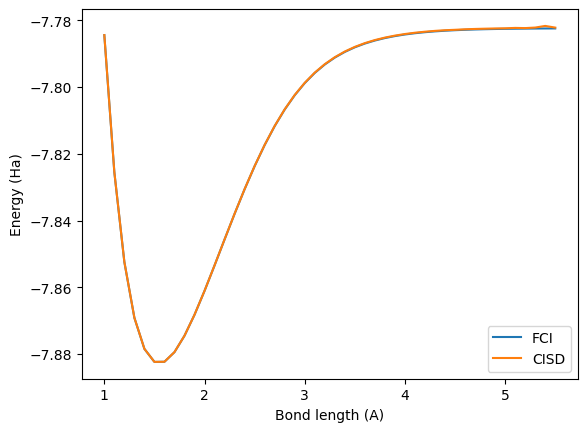

In [127]:
bls = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5]
plt.plot(bls, fci_es, label="FCI")
plt.plot(bls, cisd_es, label="CISD")
plt.xlabel("Bond length (A)")
plt.ylabel("Energy (Ha)")
plt.legend()
plt.savefig("./saved/lih_curve.png", dpi=300)

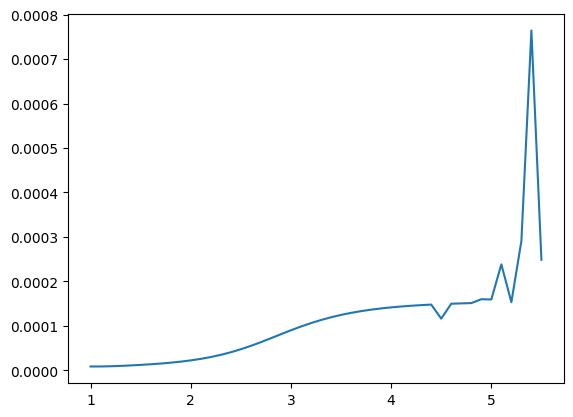

In [126]:
plt.plot(bls, np.abs(np.array(fci_es) - np.array(cisd_es)))

In [ ]:
data = (H, fci_e, fci_gs, cisd_e, cisd_wfn)
directory = "./saved/hamiltonians/"
filename = "N2frozen_eqm"
with open(directory+filename+".pkl", "wb") as f:
    pickle.dump(data, f, pickle.HIGHEST_PROTOCOL)

with open(directory+filename+".pkl", "rb") as f:
    data = pickle.load(f)

In [21]:
bshct_ent, H_perm_bshct, gs_bshct = get_ent(best_bs_hct_h2o.syms, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
bshct_bd = find_dmrg_conv_bd(H_perm_bshct, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

Symmetries rotated to Z on qubits:  [4, 0, 1, 6, 5, 2, 3]
Qubits permuted as:
0 -> 1
1 -> 2
2 -> 5
3 -> 6
4 -> 0
5 -> 4
6 -> 3
7 -> 7
8 -> 8
9 -> 9
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Entropy of cuts (bits):
1 | 2 : -3.3315635639686685e-13
2 | 3 : -3.3315635639686685e-13
3 | 4 : -3.3123430049457656e-13
4 | 5 : -3.3443772699839373e-13
5 | 6 : 0.0018209882562897981
6 | 7 : 0.0018214388629736315
7 | 8 : 0.0018241377119056375
8 | 9 : 0.9112147671837455
9 | 10 : 1.77287569593224
10 | 11 : 2.2518853919820496
11 | 12 : 2.413754329614614
12 | 13 : 1.6302566081085466
13 | 14 : 0.9103503982875277
Bond dimension:  1
Energy difference: 0.4490013633525791
Energy difference: 0.3872114259063153
Energy difference: 0.5523827356531115
Energy difference: 0.32322391471583956
Energy difference: 0.5916234643429732
Energy difference: 2.171840962395706
Energy difference: 0.5226989094830117
Energy difference: 0.697641975384073
Energy difference: 0.714707484007107
Energy difference: 3.207236702463703
Energy dif

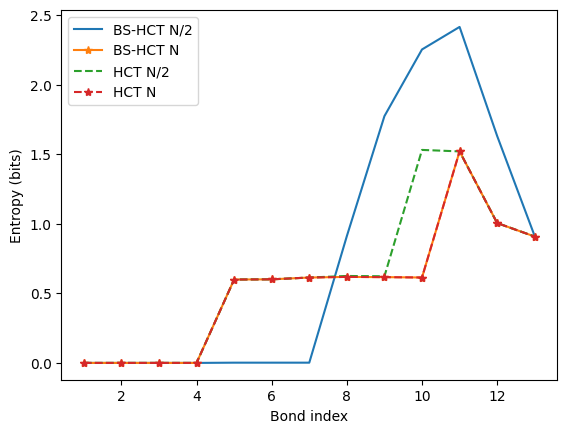

In [74]:
import matplotlib.pyplot as plt

plt.plot(range(1, n_qubits), bshct_ent, '-', label="BS-HCT N/2")
plt.plot(range(1, n_qubits), bshct_ent_N, '-*', label="BS-HCT N")
plt.plot(range(1, n_qubits), hct_ent, '--', label="HCT N/2")
plt.plot(range(1, n_qubits), hct_ent_N, '--*', label="HCT N")
plt.xlabel("Bond index")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.savefig("./saved/h2o2.1_entropy.png", dpi=300)

In [22]:
hct_ent, H_perm_hct, gs_hct = get_ent(sym_hct, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
hct_bd = find_dmrg_conv_bd(H_perm_hct, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

Symmetries rotated to Z on qubits:  [0, 1, 4, 6, 7, 5, 9]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 7
3 -> 8
4 -> 2
5 -> 5
6 -> 3
7 -> 4
8 -> 9
9 -> 6
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Entropy of cuts (bits):
1 | 2 : -3.542989713220604e-13
2 | 3 : -3.382818388029743e-13
3 | 4 : -3.613465096304585e-13
4 | 5 : -3.6198719493122194e-13
5 | 6 : 0.5990494451345876
6 | 7 : 0.6005431436846267
7 | 8 : 0.6134293020631965
8 | 9 : 0.624671788307487
9 | 10 : 0.6223793460630306
10 | 11 : 1.5301146098001375
11 | 12 : 1.5195279001920878
12 | 13 : 1.0047696236431871
13 | 14 : 0.9078590647257538
Bond dimension:  1
Energy difference: 2.707558136136555
Energy difference: 2.7075581361365835
Energy difference: 1.948581343028394
Energy difference: 2.3092844981337066
Energy difference: 1.9909344459432248
Energy difference: 2.078848516446527
Energy difference: 1.2095611581859487
Energy difference: 0.9857103944094376
Energy difference: 1.011642196744205
Energy difference: 1.7882926794721214
Energy difference: 1.

In [30]:
bshct_ent_N, H_perm_bshct_N, gs_bshct_N = get_ent(best_bs_hct_h2o_N.syms, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
bshct_N_bd = find_dmrg_conv_bd(H_perm_bshct_N, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

Symmetries rotated to Z on qubits:  [4, 0, 1, 6, 7, 5, 9, 8, 2, 3, 10, 11, 12, 13]
Qubits permuted as:
0 -> 1
1 -> 2
2 -> 8
3 -> 9
4 -> 0
5 -> 5
6 -> 3
7 -> 4
8 -> 7
9 -> 6
10 -> 10
11 -> 11
12 -> 12
13 -> 13
Entropy of cuts (bits):
1 | 2 : -3.453293771113721e-13
2 | 3 : -3.453293771113721e-13
3 | 4 : -3.453293771113721e-13
4 | 5 : -3.4597006241213556e-13
5 | 6 : 0.5990494451340407
6 | 7 : 0.6005431436840817
7 | 8 : 0.6134293020620548
8 | 9 : 0.6180219311741436
9 | 10 : 0.6163041680222977
10 | 11 : 0.6136178383976391
11 | 12 : 1.5195279001915898
12 | 13 : 1.004769623643144
13 | 14 : 0.9078590647261401
Bond dimension:  1
Energy difference: 0.991540974723577
Energy difference: 0.019665461255641503
Energy difference: 1.0395113781401193
Energy difference: 0.9748872910398063
Energy difference: 0.3256992482727412
Energy difference: 0.3285237178214402
Energy difference: 0.9759766238714889
Energy difference: 0.5028801695432605
Energy difference: 0.722748927781808
Energy difference: 0.369985215

In [64]:

sym_hct_N, eps = hct_mod(HQ, n_qubits, sym_metric_func=sym_metric_func, use_coeffs_eps=True)
hct_ent_N, H_perm_hct_N, gs_hct_N = get_ent(sym_hct_N, HQ, n_qubits, verbose=True, return_state=True)
max_bd=20
bshct_N_bd = find_dmrg_conv_bd(H_perm_hct_N, n_qubits, e, max_bd=max_bd, n_sweeps=50, reps=20)

1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z4 Z5]  added at threshold 0.0 with metric value  0.0
1.0 [Z6 Z7 Z12 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z2 Z4 Z8 Z10]  added at threshold 0.0252067961793301 with metric value  0.182823017249101
1.0 [Z4]  added at threshold 0.046509825381948124 with metric value  1.1530909282284412e-28
1.0 [Z1 Z3]  added at threshold 0.06584392974759415 with metric value  0.003303473460916225
1.0 [Z0 Z2]  added at threshold 0.06679658700501795 with metric value  0.0018108717025034867
1.0 [Z0]  added at threshold 0.13723383786881108 with metric value  4.841677111176281e-05
1.0 [Z1]  added at threshold 0.157056081153564 with metric value  9.984162050804155e-05
1.0 [Z8]  added at threshold 0.45664610143081874 with metric value  0.21706520455070824
1.0 [Z9]  added at threshold 0.4613455216244923 with metric value  0.217649599575

In [12]:
print(sym_hct)
print("BS:", sym_bs)

[1.0 [Z0 Z2 Z4 Z7 Z9 Z10], 1.0 [Z1 Z3 Z5 Z7 Z9 Z11], 1.0 [Z6 Z7], 1.0 [Z8 Z9], 1.0 [Z0 Z2 Z4 Z6 Z10], 1.0 [Z6]]
BS: [1.0 [Z0 Z2 Z4 Z7 Z9 Z10], 1.0 [Z1 Z3 Z5 Z7 Z9 Z11], 1.0 [Z6 Z7], 1.0 [Z8 Z9], 1.0 [Z0 Z1 Z2 Z3], 1.0 [Z0 Z1]]


In [8]:
best_bs_hct_lih.syms

[1.0 [Z6 Z7],
 1.0 [Z8 Z9],
 1.0 [Z0 Z2 Z4 Z6 Z8 Z10],
 1.0 [Z1 Z3 Z5 Z6 Z8 Z11],
 1.0 [Z0 Z2 Z4 Z6 Z10],
 1.0 [Z1]]

In [62]:
from src.metrics import get_BO_energies
from src.tn import find_dmrg_conv_bd
#es = get_BO_energies(HQ, best_bs_hct_h2o_N.syms, n_qubits)
min(es)

find_dmrg_conv_bd(HQ, n_qubits, e, 20, n_sweeps=50, reps=20)

/Users/praveenjayakumar/opt/anaconda3/envs/FermRefl/lib/python3.9/site-packages/pyblock2/driver/core.py:8798: ComplexWarning: Casting complex values to real discards the imaginary part
  self.data.const_e = self.data.const_e + x


Bond dimension:  1
Energy difference: 0.03298022377710197
Energy difference: 0.1749716714152214
Energy difference: 0.03298022361188657
Energy difference: 0.03298022392856126
Energy difference: 0.03298022366338671
Energy difference: 0.03298022362494635
Energy difference: 0.032980223921867946


KeyboardInterrupt: 

In [29]:
best_bs_hct_h2o_N = bs_hct(HQ, n_sym=n_qubits, use_coeffs_eps=True, sym_metric_func=sym_metric_func)

At threshold e: 0.0252067961793301, 4 new directions found!
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]  to beam  5
1
Current directions:
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]]
At threshold e: 0.046509825381948124, 4 new directions found!
A

In [36]:
from src.bs.utils import PauliMask, mask_to_qubit_operator, symplectic_commutes
from src.gf2_utils import *
from openfermion import count_qubits, QubitOperator
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
from src.op_utils import truncate_qubitop

@dataclass
class SearchStateHCT:
    basis: list
    syms: list
    score: float
    eps_list: list[float] # thresholds at which Symmetries were added

class Beam:
    """
    Beam for beam search - holds objects with a score data field to compare.
    Score is minimized!!

    """
    def __init__(self, beam_width: int, candidates = None):
        self.beam_width = beam_width
        self.candidates = [] if candidates is None else list(candidates)
    
    def sort_beam(self):
        """
        Sorts beam candidates according to score
        """
        self.candidates = sorted(self.candidates, key=lambda C: C.score, reverse=False)
    
    def num_candidates(self):
        return len(self.candidates)
    
    def prune(self):
        """
        Remove bad branches
        """
        excess = self.num_candidates() - self.beam_width
        if excess > 0:
            self.sort_beam()
            self.candidates = self.candidates[:self.beam_width]

            return excess
        else:
            return 0
    
    def add_candidate(self, candidate, check_identical_func = None, prune=False):
        """
        Adds new candidate to beam  
        optionally checks if candidate is identical to existing candidates using provided function - If found does not add new.

        """
        if check_identical_func is None:
            self.candidates.append(candidate)
        else:
            if all([check_identical_func(candidate, C) == False for C in self.candidates]):
                self.candidates.append(candidate)
        
        if prune:
            return self.prune()

    def add_candidates(self, candidates, check_identical_func = None, prune=False):
        for candidate in candidates:
            self.add_candidate(candidate, check_identical_func=check_identical_func, prune=False)
        
        if prune:
            return self.prune()

    def best_candidate(self):
        self.sort_beam()
        return self.candidates[0]

def bs_hct(HQ, n_sym=None, beam_width=16, list_sym_metric_func = None, sym_metric_func = None, use_coeffs_eps=False, num_intervals=100, eps_max=None, verbose=True, add_gen_type='rref', tol=1e-5):
    """
    HCT with BS to keep track of multiple candidates, for lower cost metric list_sym_metric_func
    stops when all candidate sets have n_sym symmetries

    HCT params
    use_coeffs_eps : if set True - then use all non-negligible coefficients as thresholds
    sym_metric_func : single symmetry ranking cost function for HCT candidate ranking
    use_coeffs_eps : Uses abs(term coeffs) for thresholds (essentially drops one term at a time)
    num_intervals : Truncation scheduling, number of divisions in max coeff - min coeffs
    add_gen_type : determines how the generating set for the candidate symmetries is formed (when there is multiple identified at one eps).

    BS params
    beam_size : number of candidate sets to keep track
    list_sym_metric_func : cost function for candidate symmetry set (defaults to average of sym_metric_func)

    """
    def extend_candidates(candidates, new_direction, n_qubits, eps=0):
        new_candidates = []

        for candidate in candidates:
            #check if new direction is commuting and new
            if gf2_rank(concatenate_matrices(candidate.basis, np.array([new_direction]))) > gf2_rank(candidate.basis) and gf2_check_commuting(np.array([new_direction]), candidate.basis, n_qubits):
                new_basis = concatenate_matrices(candidate.basis, np.array([new_direction]))
                new_syms = candidate.syms + [QubitOperator(symplectic_to_pauli_string(new_direction, n_qubits), 1.0)]
                new_candidates.append(SearchStateHCT(new_basis, syms = new_syms, score=list_sym_metric_func(new_syms), eps_list=candidate.eps_list+[eps]))
        
        return new_candidates

    def check_same_func(A, B):
        ra, rb, rab = gf2_rank(A.basis), gf2_rank(B.basis), gf2_rank(concatenate_matrices(A.basis, B.basis))
        return ra == rb and ra == rab

    n_qubits = count_qubits(HQ)
    max_abs = max((abs(c) for c in HQ.terms.values()), default=0.0)

    #defaults
    if n_sym is None: n_sym = n_qubits
    if sym_metric_func is None: sym_metric_func = lambda sym: np.real(universal_grading([sym], HQ)) # Pauli L1 of NC
    if list_sym_metric_func is None: list_sym_metric_func = lambda sym_list: np.sum([sym_metric_func(sym) for sym in sym_list])
    if eps_max is None: eps_max = max_abs * 1.000001

    #input checks
    assert n_sym <= n_qubits, "Invalid number of symmetries {} requested for {} qubit Hamiltonian".format(n_sym, n_qubits)

    if use_coeffs_eps:
        eps_grid = [0.0]
        eps_grid.extend(sorted([np.abs(c) for c in truncate_qubitop(HQ, tol).terms.values()]))
    else:
        eps_grid = np.linspace(0.0, eps_max, num_intervals)
    
    # init with exact symmetries
    G, _, _, _ = qubitop_to_G_matrix(HQ, n=n_qubits)
    directions = gf2_symp_nullspace(G, n_qubits, True)
    exact_syms = [QubitOperator(symplectic_to_pauli_string(c, n_qubits), 1.0) for c in directions]
    n_exact_syms = len(exact_syms)
    init_candidate = SearchStateHCT(directions, exact_syms, list_sym_metric_func(exact_syms), [0]*n_exact_syms)

    if n_exact_syms >= n_sym:
        return init_candidate

    beams = {}
    for num_syms in range(n_exact_syms, n_sym+1):
        beams[num_syms] = Beam(beam_width=beam_width)
    pruned = beams[n_exact_syms].add_candidate(init_candidate, prune=True)

    #start beaming!
    for idx, eps in enumerate(eps_grid):
        # Truncate H
        Ht = truncate_qubitop(HQ, float(eps))

        G, _, _, _ = qubitop_to_G_matrix(Ht, n=n_qubits)
        S_de = gf2_symp_nullspace(G, n_qubits, True)

        # # SS = Sde \int null_symp(S) generating set for new symmetries commute with existing
        # SS = gf2_intersection(S_de, gf2_symp_nullspace(S, n_qubits), n_qubits)

        # SS\S ensuring generating set is "new" (ie increases gf2 rank when appended to S)
        new_directions = gf2_complement(S_de, directions)
        
        if len(new_directions) == 0:
            #no new directions identified
            continue
        
        if verbose:
            print("At threshold e: {}, {} new directions found!".format(eps, len(new_directions)))

        # modify generating set to satisfy some desirable property TODO (or) generate candidate pool to consider (for generalization)
        if add_gen_type == 'rref':
            new_directions, _ = gf2_rref(new_directions)
        
        #attempt adding to beams upto n_sym-1
        for new_direction in new_directions:
            for sym_count in reversed(range(n_exact_syms, n_sym)):
                beam = beams[sym_count]
                if beam.num_candidates() > 0:
                    if verbose: print("Adding ", new_direction, " to beam ", sym_count+1)
                    new_candidates = extend_candidates(beam.candidates, new_direction=new_direction, n_qubits=n_qubits, eps=eps)
                    print(len(new_candidates))
                    pruned += beams[sym_count+1].add_candidates(new_candidates, check_identical_func=check_same_func, prune=True)
        
        ### this should be fixed
        directions = S_de
        print("Current directions:\n", directions)
    
    if verbose: print("Completed search, {} pruned branches.".format(pruned))

    if beams[n_sym].num_candidates() == 0:
        print("No sufficient candidates found, debugging required!!")
        return beams
    
    best =  beams[n_sym].best_candidate()
    if verbose: 
        print("Best candidate with score: {}".format(best.score))
        for sym in best.syms:
            print(sym)
    
    return best, beams

best_bs_hct_N, beams = bs_hct(HQ, n_sym=n_qubits, use_coeffs_eps=True, sym_metric_func=sym_metric_func)

At threshold e: 0.0252067961793301, 4 new directions found!
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]  to beam  5
1
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]  to beam  6
0
Adding  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]  to beam  5
1
Current directions:
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]]
At threshold e: 0.046509825381948124, 4 new directions found!
A

In [53]:
best_bs_hct_h2o.syms

[1.0 [Z4 Z5],
 1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11],
 1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12],
 1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13],
 1.0 [Z4],
 1.0 [Z0],
 1.0 [Z1]]

In [70]:
hct_ent
hct_ent_N

bshct_ent_N
bshct_ent

[-3.3315635639686685e-13,
 -3.3315635639686685e-13,
 -3.3123430049457656e-13,
 -3.3443772699839373e-13,
 0.0018209882562897981,
 0.0018214388629736315,
 0.0018241377119056375,
 0.9112147671837455,
 1.77287569593224,
 2.2518853919820496,
 2.413754329614614,
 1.6302566081085466,
 0.9103503982875277]

In [41]:
best_bs_hct_N.syms

[1.0 [Z4 Z5],
 1.0 [Z0 Z1 Z2 Z3 Z8 Z9 Z10 Z11],
 1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12],
 1.0 [Z0 Z2 Z4 Z7 Z8 Z10 Z13],
 1.0 [Z0 Z2 Z4 Z8 Z10],
 1.0 [Z0 Z2 Z8 Z10],
 1.0 [Z1 Z3],
 1.0 [Z0 Z2],
 1.0 [Z0],
 1.0 [Z1],
 1.0 [Z8],
 1.0 [Z9],
 1.0 [Z6],
 1.0 [Z7]]

In [ ]:
# perturbative measure, ||V||_1/Delta E_0
from src.metrics import l1norm

def get_ent_pert(HQ, symmetries, n_qubits):
    """
    Does get ent stuff and returns perturbative measure

    ||V||_1/Delta E_0
    """

    for k in range(1, n_qubits):
        sym_k = symmetries[:k]

        HQ_red = 
        H0 = get_commutant(HQ_red, sym_k)
        H0s = get_sparse_operator(H0, n_qubits)
        V = HQ_red - H0
        V.compress()

        l1norm(V)/


In [40]:
get_ent(best_bs_hct.syms, HQ, n_qubits, True)


Symmetries rotated to Z on qubits:  [6, 0, 1, 10, 4, 8, 9, 5, 7, 13, 12, 11, 2, 3]
Qubits permuted as:
0 -> 1
1 -> 2
2 -> 12
3 -> 13
4 -> 4
5 -> 7
6 -> 0
7 -> 8
8 -> 5
9 -> 6
10 -> 3
11 -> 11
12 -> 10
13 -> 9
Entropy of cuts (bits):
1 | 2 : -1.8626003064142167e-11
2 | 3 : -1.862472169354059e-11
3 | 4 : -1.8589484001997263e-11
4 | 5 : -1.859012468729805e-11
5 | 6 : 9.325642496067277e-06
6 | 7 : 0.013589402709801978
7 | 8 : 1.0094913988656322
8 | 9 : 0.6529287340972989
9 | 10 : 0.6530999912165025
10 | 11 : 1.545561415894893
11 | 12 : 0.919929031119459
12 | 13 : 1.6216310804656038e-05
13 | 14 : 1.1549854420443874e-05


([-1.8626003064142167e-11,
  -1.862472169354059e-11,
  -1.8589484001997263e-11,
  -1.859012468729805e-11,
  9.325642496067277e-06,
  0.013589402709801978,
  1.0094913988656322,
  0.6529287340972989,
  0.6530999912165025,
  1.545561415894893,
  0.919929031119459,
  1.6216310804656038e-05,
  1.1549854420443874e-05],
 -47.56858591958542 [] +
 0.22003977334376132 [Z0] +
 0.002517203791842881 [Z0 Z1 Z2 Z3 X4 X5 X6 Z7 Z8 Z9 Z11 Z12 X13] +
 -0.001599967787036542 [Z0 Z1 Z2 Z3 X4 X5 X6 Z7 Z8 Z9 Z11 Z13] +
 -0.000249623031097642 [Z0 Z1 Z2 Z3 X4 X5 Y6 Z7 Z8 Y12 Z13] +
 0.002517203791842881 [Z0 Z1 Z2 Z3 X4 X5 Y6 Z7 Z8 Z12 Y13] +
 -0.0022675807607452384 [Z0 Z1 Z2 Z3 X4 X5 Z7 Z8 Z9 Z11 X12 Z13] +
 -0.000249623031097642 [Z0 Z1 Z2 Z3 X4 X5 Z7 Z8 Z9 Z11 Z12 X13] +
 0.001599967787036542 [Z0 Z1 Z2 Z3 X4 X5 Z7 Z8 Z9 Z11 Z13] +
 -0.0022675807607452384 [Z0 Z1 Z2 Z3 X4 Y5 Z6 Z7 Z8 Y12 Z13] +
 0.007542839550206601 [Z0 Z1 Z2 Z3 Z4 X5 Z6 Z8 Z12] +
 -0.007772937126154802 [Z0 Z1 Z2 Z3 Z4 Y5 X6 Y7 Z8 Z9 Z11 Z12] +

In [ ]:
get_ent(hct_sym_all[0], HQ, n_qubits, True)

1 | 2 : -1.8626003064142167e-11
2 | 3 : -1.862472169354059e-11
3 | 4 : -1.8589484001997263e-11
4 | 5 : -1.859012468729805e-11
5 | 6 : 9.325642496067277e-06
6 | 7 : 0.013589402709801978
7 | 8 : 1.0094913988656322
8 | 9 : 0.6529287340972989
9 | 10 : 0.6530999912165025
10 | 11 : 1.545561415894893
11 | 12 : 0.919929031119459
12 | 13 : 1.6216310804656038e-05
13 | 14 : 1.1549854420443874e-05


Symmetries rotated to Z on qubits:  [0, 1, 6, 10, 4, 8, 9, 5, 7, 13, 12, 11, 2, 3]
Qubits permuted as:
0 -> 0
1 -> 1
2 -> 12
3 -> 13
4 -> 4
5 -> 7
6 -> 2
7 -> 8
8 -> 5
9 -> 6
10 -> 3
11 -> 11
12 -> 10
13 -> 9
Entropy of cuts (bits):
1 | 2 : -2.419612106922354e-11
2 | 3 : -2.3943050375409497e-11
3 | 4 : -2.3883466642435577e-11
4 | 5 : -2.387962253063081e-11
5 | 6 : 9.325637147730104e-06
6 | 7 : 0.013589399064513268
7 | 8 : 1.009491396380082
8 | 9 : 0.6529287295561005
9 | 10 : 0.6530999866766254
10 | 11 : 1.5455614156570974
11 | 12 : 0.9199290292679513
12 | 13 : 1.6216304951232176e-05
13 | 14 : 1.1549848818426151e-05


([-2.419612106922354e-11,
  -2.3943050375409497e-11,
  -2.3883466642435577e-11,
  -2.387962253063081e-11,
  9.325637147730104e-06,
  0.013589399064513268,
  1.009491396380082,
  0.6529287295561005,
  0.6530999866766254,
  1.5455614156570974,
  0.9199290292679513,
  1.6216304951232176e-05,
  1.1549848818426151e-05],
 -47.56858591958542 [] +
 -0.00038330121110388026 [Z0 Z1 Z2 Z3 X4 X5 Z6 X10 Z11] +
 -2.3363266702903777e-05 [Z0 Z1 Z2 Z3 X4 X5 Z6 Z10] +
 -1.9586311709278803e-05 [Z0 Z1 Z2 X4 X5] +
 0.001599967787036542 [Z0 Z1 Z2 X4 X5 X6] +
 -9.198259972141156e-05 [Z0 Z1 Z2 X4 X5 X6 X7] +
 -0.0001118561470327116 [Z0 Z1 Z2 X4 X5 X6 X8] +
 7.311109362196401e-05 [Z0 Z1 Z2 X4 X5 X6 X12 X13] +
 -9.198259972141156e-05 [Z0 Z1 Z2 X4 X5 Y6 Y7 Z9 Z11] +
 -0.0001118561470327116 [Z0 Z1 Z2 X4 X5 Y6 Y8 Z9 Z11] +
 7.311109362196401e-05 [Z0 Z1 Z2 X4 X5 Y6 Z9 Z11 X12 Y13] +
 0.000249623031097642 [Z0 Z1 Z2 X4 X5 Y6 Z9 Z11 Y12] +
 5.38404778861476e-05 [Z0 Z1 Z2 X4 X5 Z6 Z7 Z9 Z11] +
 5.269788084831696e-05 [Z0

In [41]:
hct_sym_all =  hct_mod(HQ, n_qubits, sym_metric_func=sym_metric_func, use_coeffs_eps=True)

1.0 [Z0 Z2 Z4 Z7 Z8 Z11 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z10 Z11 Z12 Z13]  added at threshold 0.0 with metric value  0.0
1.0 [Z0 Z1 Z2 Z3]  added at threshold 0.008950513867521425 with metric value  6.504316500284481e-05
1.0 [Z4 Z5]  added at threshold 0.043016812933517785 with metric value  0.0061533277432136955
1.0 [Z0 Z2 Z4 Z7]  added at threshold 0.04304868404153836 with metric value  0.004809008236666034
1.0 [Z0 Z2 Z7]  added at threshold 0.043090033809578474 with metric value  0.00014133596524544274
1.0 [Z6]  added at threshold 0.04384229148167628 with metric value  7.415878809613074e-06
1.0 [Z8 Z11]  added at threshold 0.08265329495024275 with metric value  0.005054944848011924
1.0 [Z12]  added at threshold 0.08265329495024275 with metric value  0.006621572425585231
1.0 [Z9]  added at threshold 0.11052464819817961 with met

In [36]:
best_bs_hct[7].best_candidate().syms

[1.0 [Z6 Z7],
 1.0 [Z0 Z1 Z2 Z3 Z4 Z5 Z8 Z9],
 1.0 [Z0 Z2 Z4 Z6 Z8 Z10 Z12],
 1.0 [Z0 Z2 Z4 Z6 Z8 Z11 Z13],
 1.0 [Z6],
 1.0 [Z0],
 1.0 [Z1]]

In [19]:
from src.metrics import entropy_pauli_syms
entropy_pauli_syms(best_bs_hct.syms, gs, n_qubits)

(1.5769443826170186+0j)

In [16]:
print(universal_grading(sym_hct, HQ))

print(entropy_pauli_syms(sym_hct, gs, n_qubits))

2.823849280985283
(2.2446523580453923+0j)


In [22]:
universal_grading(sym_bs, HQ)
universal_grading(best_bs_hct.syms, HQ)

4.398071599552456

In [116]:
hct_s, _  = hct_mod(HQ, 4, use_coeffs_eps=True)

1.0 [Z0 Z3 Z4 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z3 Z5 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z2 Z3 Z6 Z7]  added at threshold 0.0 with metric value  0.0
1.0 [Z1 Z2 Z4 Z7]  added at threshold 0.02616133069920393 with metric value  2.598863007700321


In [ ]:
### full clifford from factors, needs testing!
from __future__ import annotations
from typing import List, Optional, Sequence, Tuple
import numpy as np
import scipy.sparse as sp

from openfermion import QubitOperator, get_sparse_operator


def I_op() -> QubitOperator:
    return QubitOperator(())

def X_op(q: int) -> QubitOperator:
    return QubitOperator(((q, 'X'),))

def Y_op(q: int) -> QubitOperator:
    return QubitOperator(((q, 'Y'),))

def Z_op(q: int) -> QubitOperator:
    return QubitOperator(((q, 'Z'),))


def H_factor(q: int) -> QubitOperator:
    """
    H = (X + Z) / sqrt(2)
    """
    return (X_op(q) + Z_op(q)) / np.sqrt(2.0)


def Sdg_factor(q: int) -> QubitOperator:
    """
    S^\dagger = ((1-i)/2) I + ((1+i)/2) Z
    """
    return ((1.0 - 1.0j) / 2.0) * I_op() + ((1.0 + 1.0j) / 2.0) * Z_op(q)


def S_factor(q: int) -> QubitOperator:
    """
    S = ((1+i)/2) I + ((1-i)/2) Z
    """
    return ((1.0 + 1.0j) / 2.0) * I_op() + ((1.0 - 1.0j) / 2.0) * Z_op(q)


def CNOT_factor(control: int, target: int) -> QubitOperator:
    """
    CNOT(control -> target)
      = |0><0|_c ⊗ I_t + |1><1|_c ⊗ X_t
      = 1/2 (I + Z_c + X_t - Z_c X_t)
    """
    return 0.5 * (
        I_op()
        + Z_op(control)
        + X_op(target)
        - Z_op(control) * X_op(target)
    )


def factor_description_to_qubit_operator(desc: str) -> QubitOperator:
    """
    Convert one factor description like 'H(2)' or 'CNOT(1->3)'
    into the corresponding QubitOperator.
    """
    if desc.startswith("H("):
        q = int(desc[2:].strip("()"))
        return H_factor(q)

    if desc.startswith("Sdg("):
        q = int(desc[4:].strip("()"))
        return Sdg_factor(q)

    if desc.startswith("S("):
        q = int(desc[2:].strip("()"))
        return S_factor(q)

    if desc.startswith("CNOT("):
        inside = desc[5:].strip("()")
        c, t = inside.split("->")
        return CNOT_factor(int(c), int(t))

    raise ValueError(f"Unknown factor description: {desc}")

def build_clifford_as_sparse_matrix(
    factor_descriptions: Sequence[str],
    n_qubits: int,
    sparse_format: str = "csc",
) -> sp.spmatrix:
    """
    Build the full Clifford unitary as a sparse matrix.

    Returns U such that if the factors were [U1, U2, ..., Um],
    the result is:
        U = Um ... U2 U1

    which matches the operator multiplication convention used in the
    previous synthesis code.
    """
    dim = 2 ** n_qubits
    U = sp.identity(dim, dtype=complex, format=sparse_format)

    for desc in factor_descriptions:
        print(desc)
        U_factor_op = factor_description_to_qubit_operator(desc)
        print(U_factor_op)
        U_factor_mat = get_sparse_operator(U_factor_op, n_qubits=n_qubits).asformat(sparse_format)
        U = U_factor_mat @ U

    return U

U = build_clifford_as_sparse_matrix(res.clifford_result.factor_descriptions, n_qubits)

H(4)
0.7071067811865475 [X4] +
0.7071067811865475 [Z4]
H(5)
0.7071067811865475 [X5] +
0.7071067811865475 [Z5]
H(6)
0.7071067811865475 [X6] +
0.7071067811865475 [Z6]
H(7)
0.7071067811865475 [X7] +
0.7071067811865475 [Z7]
CNOT(4->5)
0.5 [] +
0.5 [Z4] +
-0.5 [Z4 X5] +
0.5 [X5]
CNOT(4->6)
0.5 [] +
0.5 [Z4] +
-0.5 [Z4 X6] +
0.5 [X6]
CNOT(4->7)
0.5 [] +
0.5 [Z4] +
-0.5 [Z4 X7] +
0.5 [X7]
H(4)
0.7071067811865475 [X4] +
0.7071067811865475 [Z4]
H(0)
0.7071067811865475 [X0] +
0.7071067811865475 [Z0]
H(3)
0.7071067811865475 [X3] +
0.7071067811865475 [Z3]
CNOT(0->3)
0.5 [] +
0.5 [Z0] +
-0.5 [Z0 X3] +
0.5 [X3]
CNOT(0->5)
0.5 [] +
0.5 [Z0] +
-0.5 [Z0 X5] +
0.5 [X5]
CNOT(0->6)
0.5 [] +
0.5 [Z0] +
-0.5 [Z0 X6] +
0.5 [X6]
H(0)
0.7071067811865475 [X0] +
0.7071067811865475 [Z0]
H(1)
0.7071067811865475 [X1] +
0.7071067811865475 [Z1]
CNOT(1->3)
0.5 [] +
0.5 [Z1] +
-0.5 [Z1 X3] +
0.5 [X3]
CNOT(1->5)
0.5 [] +
0.5 [Z1] +
-0.5 [Z1 X5] +
0.5 [X5]
CNOT(1->7)
0.5 [] +
0.5 [Z1] +
-0.5 [Z1 X7] +
0.5 [X7]
H(1)
0.707

In [26]:
from src.metrics import entropy
import matplotlib.pyplot as plt
from src.clifford import *
def get_entropies_at_cuts(state, n_qubits):
    entropies = []
    for k in range(1, n_qubits):
        u, d, v = np.linalg.svd(np.reshape(state, (1<<k, 1<<(n_qubits-k))))

        entropies.append(entropy(d**2))
    return entropies

def get_ent(symmetries, HQ, n_qubits):
    res = build_symmetry_block_structure_with_packed_qubits(
        hamiltonian=HQ,
        symmetries=symmetries,
        n_qubits=n_qubits,
    )

    #permute symmetries to the start
    H_trans = res.transformed_hamiltonian
    sym_mapped_qubits = res.original_mapped_qubits

    #syms to start + rest in order
    print(sym_mapped_qubits)
    n_sym = len(sym_mapped_qubits) #locations of symmetry qubits - should go to the beginning
    perm = []
    ns=0
    nns =0
    for i in range(n_qubits): #qubit count
        if i in sym_mapped_qubits: 
            assert ns < n_sym, "Too many symmetry indices!"
            perm.append(sym_mapped_qubits.index(i))
            ns +=1
        else:
            perm.append(n_sym + nns)
            nns += 1

    print(perm)

    H_perm = permute_qubits_in_qubit_operator(H_trans, perm)
    e_p, gs = get_ground_state(get_sparse_operator(H_perm, n_qubits))
    print(e_p)
    return get_entropies_at_cuts(gs, n_qubits), H_perm

#get_ent(sym_hct, HQ, n_qubits)
# #e, gs = get_ground_state(get_sparse_operator(HQ, n_qubits))
# # print(e)
# ent_og = get_entropies_at_cuts(gs, n_qubits)
# print(ent_og)
# # # print(ent_og)

# ent_hct = get_ent(sym_hct, HQ, n_qubits)
# ent_sen = get_ent(sym_sen, HQ, n_qubits)
# ent_bs = get_ent(sym_bs, HQ, n_qubits)

# plt.plot(range(1, n_qubits), ent_og, label="OG")
# plt.plot(range(1, n_qubits), ent_hct[0], label="HCT")
# plt.plot(range(1, n_qubits), ent_sen[0], label="Sen")
# plt.plot(range(1, n_qubits), ent_bs[0], label="BS")
# # #plt.plot(range(1, n_qubits), al, label="HCT all")
# plt.legend()

In [36]:
get_ent([QubitOperator('Z0 Z1', 1.0), QubitOperator('Z1', 1.0)], QubitOperator('X0 X1', -1.0), 2)

[0, 1]
[0, 1]
-0.9999999999999999


([-6.40685300762984e-16], -1.0 [X1])

In [30]:
sym_hct_all, hct_all_eps = find_approx_symm(HQ, n_qubits)
ent_hct_all = get_ent(sym_hct_all, HQ, n_qubits)

sym_bs_all = find_commuting_symmetry_generators(
    HQ,
    target_rank=n_qubits,
    beam_width=16,
    heavy_core_fraction=0.95,
    include_pairwise_products=True,
    pairwise_seed_terms=12,
    seed_with_exact_symmetries=True,
    #score_func=lambda s: -comm_sq_exp_fast(s, Hs, gs, n_qubits)# Change or remove as needed #variance(s, cisd_wfn, n_qubits) # 
)
ent_sym_bs_all = get_ent(sym_bs_all, HQ, n_qubits)

Added Pauli string: 1.0 [Z6 Z7 Z12 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z4 Z5] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z5] at threshold: 0.4802901640293906 with metric value: 1.0384480445408846
Added Pauli string: 1.0 [Z2] at threshold: 0.4802901640293906 with metric value: 5.332034886889228
Added Pauli string: 1.0 [Z3] at threshold: 0.4802901640293906 with metric value: 5.332034886889229
Added Pauli string: 1.0 [Z7] at threshold: 0.4802901640293906 with metric value: 7.679225298043392
Added Pauli string: 1.0 [Z13] at threshold: 0.4802901640293906 with metric value: 7.719717232749654
Added Pauli string: 1.0 [Z12] at threshold: 0.4802901640293906 with metric value: 7.719717232749655
Added Pauli string: 1.0 [Z9] at threshold: 0.4802901640293906 with me

In [ ]:
sym_hct_all, hct_all_eps = find_approx_symm(HQ, n_qubits) ### WTF

Added Pauli string: 1.0 [Z10 Z11 Z12 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z6 Z7] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13] at threshold: 0.0 with metric value: 0.0
Added Pauli string: 1.0 [Z0 Z2 Z4 Z7 Z8 Z11 Z13] at threshold: 0.0 with metric value: 0.0
Excessive symmetries found, ranking and selecting best.
Selected symmetries:
1.0 [Z7]  with metric value  0.753415853297308
1.0 [Z4]  with metric value  1.197208896724063
1.0 [Z5]  with metric value  1.1972088967240633
1.0 [Z9]  with metric value  1.3184386223842566
1.0 [Z8]  with metric value  1.3184386223842568
1.0 [Z11]  with metric value  1.331874787040197
1.0 [Z13]  with metric value  1.366139006641971
1.0 [Z12]  with metric value  1.366139006641971
1.0 [X9]  with metric value  2.704535706424673
1.0 [X10]  with metric value  2.7150984778838416


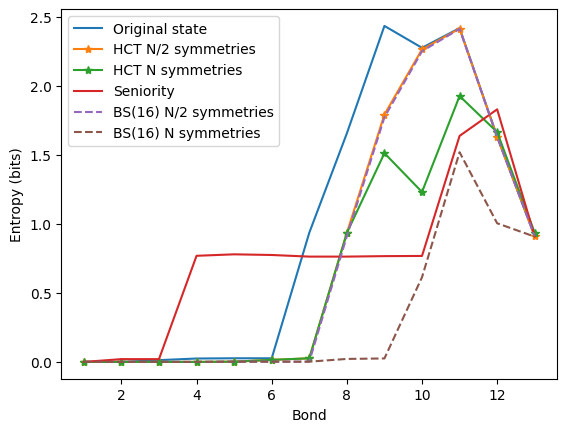

In [32]:
plt.plot(range(1, n_qubits), ent_og, label="Original state")
plt.plot(range(1, n_qubits), ent_hct[0], '-*', label="HCT N/2 symmetries")
plt.plot(range(1, n_qubits), ent_hct_all[0], '-*', label="HCT N symmetries")
plt.plot(range(1, n_qubits), ent_sen[0], label="Seniority")
plt.plot(range(1, n_qubits), ent_bs[0], '--', label="BS(16) N/2 symmetries")
plt.plot(range(1, n_qubits), ent_sym_bs_all[0], '--', label="BS(16) N symmetries")

plt.xlabel("Bond")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.savefig("./saved/bi_ent_h2o_2.1.png")

In [35]:
sym_bs_all

[1.0 [Z0 Z2 Z5 Z7 Z8 Z10 Z13],
 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13],
 1.0 [Z4 Z5],
 1.0 [Z6 Z7 Z12 Z13],
 1.0 [Z5],
 1.0 [Z0],
 1.0 [Z1],
 1.0 [Z2 Z3],
 1.0 [Z3],
 1.0 [Z8 Z10],
 1.0 [Z9],
 1.0 [Z8],
 1.0 [Z6],
 1.0 [Z7]]

In [ ]:
sym_mapped_qubits = [4, 2]

n_qubits =6
n_sym = len(sym_mapped_qubits) #locations of symmetry qubits - should go to the beginning
perm = []
ns=0
nns =0
for i in range(n_qubits): #qubit count
    if i in sym_mapped_qubits: 
        assert ns < n_sym, "Too many symmetry indices!"
        perm.append(sym_mapped_qubits.index(i))
        ns +=1
    else:
        perm.append(n_sym + nns)
        nns += 1

print(perm)

from openfermion import QubitOperator
from src.clifford import permute_qubits_in_qubit_operator
QO = QubitOperator('X0 Y1 Z2 Z3 Z4', 1.0) +  QubitOperator('Y0 Z2', 2.0)
permute_qubits_in_qubit_operator(QO, perm)

[2, 3, 1, 4, 0, 5]


1.0 [Z0 Z1 X2 Y3 Z4] +
2.0 [Z1 Y2]

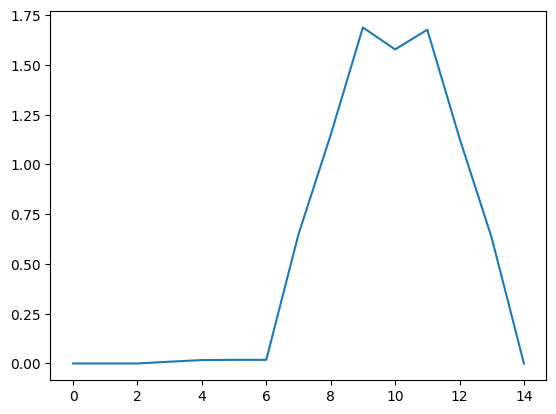

In [9]:
import numpy as np


def bipartite_von_neumann_entropy_from_state(
    psi: np.ndarray,
    n_qubits: int,
    cut: int,
    log_base: float = np.e,
    check_normalized: bool = True,
) -> float:
    """
    Entanglement entropy across the cut:
        A = qubits [0, ..., cut-1]
        B = qubits [cut, ..., n_qubits-1]

    Parameters
    ----------
    psi : np.ndarray
        Statevector of shape (2**n_qubits,).
    n_qubits : int
        Number of qubits.
    cut : int
        Size of subsystem A.
    log_base : float
        Use np.e for nats, 2 for bits.
    check_normalized : bool
        Whether to verify normalization.

    Returns
    -------
    float
        von Neumann entropy S(A) = -Tr(rho_A log rho_A).
    """
    psi = np.asarray(psi, dtype=complex).reshape(-1)

    if psi.shape[0] != 2**n_qubits:
        raise ValueError("Statevector length does not match n_qubits.")

    if not (0 <= cut <= n_qubits):
        raise ValueError("cut must satisfy 0 <= cut <= n_qubits.")

    if check_normalized:
        norm = np.vdot(psi, psi).real
        if not np.isclose(norm, 1.0, atol=1e-10):
            raise ValueError(f"Statevector is not normalized. Norm = {norm}")

    # Edge cuts: entropy is zero for empty/full subsystem.
    if cut == 0 or cut == n_qubits:
        return 0.0

    # Reshape into Schmidt matrix Psi_{a,b}
    psi_matrix = psi.reshape(2**cut, 2**(n_qubits - cut))

    # Singular values are Schmidt coefficients
    svals = np.linalg.svd(psi_matrix, compute_uv=False)
    probs = svals**2

    # Numerical cleanup
    probs = probs[probs > 1e-15]

    if log_base == np.e:
        logs = np.log(probs)
    elif log_base == 2:
        logs = np.log2(probs)
    else:
        logs = np.log(probs) / np.log(log_base)

    return float(-np.sum(probs * logs))


def bipartite_entropy_curve(
    psi: np.ndarray,
    n_qubits: int,
    log_base: float = np.e,
) -> np.ndarray:
    """
    Return S_vN(cut) for cut = 0, 1, ..., n_qubits.
    """
    return np.array([
        bipartite_von_neumann_entropy_from_state(
            psi=psi,
            n_qubits=n_qubits,
            cut=cut,
            log_base=log_base,
        )
        for cut in range(n_qubits + 1)
    ])

plt.plot(bipartite_entropy_curve(gs, n_qubits))

In [ ]:
res = build_symmetry_block_structure_with_packed_qubits(
    hamiltonian=HQ,
    symmetries=sym_hct,
    n_qubits=n_qubits,
)
res.clifford_result.mapped_qubits

[7, 3, 6, 5, 4, 0, 1, 2]

In [20]:
#non comm hf

from src.state_utils import get_hf_occ, get_hf_wfn, get_fci_state_from_molecule

hf_occ = get_hf_occ(molecule.n_electrons, molecule.n_orbitals)
hf_wfn = get_hf_wfn(hf_occ)

def comm_sq_exp(sym_ops, HQ, state, n_qubits):
    """
    sym_ops list[QubitOperator] (Pauli products)

    state np.array

    """
    HQs = get_sparse_operator(HQ, n_qubits)
    sym_s = [get_sparse_operator(sym, n_qubits) for sym in sym_ops]

    comms = [1.j*commutator(HQs, sym) for sym in sym_s]
    return np.sum([expectation(comm @ comm , state) for comm in comms])

comm_sq_exp(sym_hct, HQ, hf_wfn, n_qubits)

%timeit comm_sq_exp_hf(sym_hct, HQ, hf_occ)

806 ms ± 14 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
import numpy as np
from openfermion import commutator

def is_diagonal_pauli_term(term):
    """
    term: tuple like ((0, 'Z'), (3, 'Z'))
    Returns True iff term contains only Z operators (I is absent implicitly).
    """
    return all(pauli == 'Z' for _, pauli in term)

def pauli_z_eigenvalue_on_bitstring(term, bitstring):
    """
    Evaluate <b|P|b> for a diagonal Pauli term P on computational basis state |b>.

    Parameters
    ----------
    term : tuple
        OpenFermion Pauli term representation, e.g. ((0, 'Z'), (3, 'Z'))
    bitstring : sequence[int]
        Occupation / computational basis bits, length n_qubits, values 0 or 1

    Returns
    -------
    int
        ±1
    """
    eig = 1
    for q, pauli in term:
        if pauli != 'Z':
            return 0
        eig *= -1 if bitstring[q] else 1
    return eig

def comm_sq_exp_hf_single_sym(sym_op, HQ, bitstring):
    """
    Compute <HF| ( i[H, S] )^2 |HF> using symbolic Pauli algebra only.

    Parameters
    ----------
    sym_op : QubitOperator
        One Pauli-product symmetry operator S.
    HQ : QubitOperator
        Hamiltonian.
    bitstring : sequence[int]
        HF determinant in computational-basis / occupation representation.

    Returns
    -------
    float
    """
    C = 1j * commutator(HQ, sym_op)   # symbolic operator
    C2 = C * C                        # symbolic Pauli expansion

    total = 0.0 + 0.0j
    for term, coeff in C2.terms.items():
        if is_diagonal_pauli_term(term):
            total += coeff * pauli_z_eigenvalue_on_bitstring(term, bitstring)

    return float(np.real_if_close(total))

def comm_sq_exp_hf(sym_ops, HQ, bitstring):
    """
    Sum_k <HF| ( i[H, S_k] )^2 |HF>.
    """
    return sum(comm_sq_exp_hf_single_sym(sym, HQ, bitstring) for sym in sym_ops)

In [13]:
comm = 1.j*get_sparse_operator(commutator(HQ, syms[4]))
print("hey")
from openfermion import expectation
expectation(comm @ comm, hf_wfn)

hey


(0.4162019677952294+0j)

In [14]:
commutator(comm, comm)

<16384x16384 sparse matrix of type '<class 'numpy.complex128'>'
	with 0 stored elements in Compressed Sparse Column format>

In [89]:
#syms = sym_all[:4] + [QubitOperator('Z6', 1.0), QubitOperator('Z8', 1.0)]
print("HCT:\n{}\n{}".format(syms, universal_grading(syms, HQ)))

find_commuting_paulis(HQ, syms)

entropy_pauli_syms(syms, gs, n_qubits)

HCT:
[1.0 [Z0 Z2 Z5 Z6 Z9 Z10 Z13], 1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13], 1.0 [Z4 Z5 Z12 Z13], 1.0 [Z8 Z9], 1.0 [Z8], 1.0 [Z0], 1.0 [Z1]]
8.72264398733759
558/1086 Terms in H found to commuting with all symmetries.


(0.00970958823587644+3.520912706563328e-17j)

In [77]:
H = get_fermion_operator(molecule.get_molecular_hamiltonian())
sym_all, eps = find_approx_symm(jordan_wigner(H), n_qubits)

Added Pauli string: Z8 Z9 at threshold: 0.0
Added Pauli string: Z6 Z7 at threshold: 0.0
Added Pauli string: Z1 Z3 Z5 Z7 Z9 Z11 at threshold: 0.0
Added Pauli string: Z0 Z2 Z4 Z7 Z9 Z10 at threshold: 0.0
Added Pauli string: Z11 at threshold: 0.041776477932657784
Added Pauli string: Z10 at threshold: 0.041776477932657784
Added Pauli string: Z9 at threshold: 0.041776477932657784
Added Pauli string: Z7 at threshold: 0.041776477932657784
Added Pauli string: Z5 at threshold: 0.041776477932657784
Added Pauli string: Z4 at threshold: 0.041776477932657784
Added Pauli string: Z3 at threshold: 0.041776477932657784
Added Pauli string: Z2 at threshold: 0.041776477932657784


In [31]:
i, j, a, b = 0, 1, 2, 3
print(QubitOperator('Z{} Z{} X{} X{}'.format(a, b, b, a)))

print(QubitOperator('Y{} Y{}'.format(a, b)))

(-1+0j) [Y2 Y3]
1.0 [Y2 Y3]


In [3]:
### orbital optimization with jax with seniority symmetries

from src.orbital_rotation import RealOrbitalRotation
import numpy as np
from openfermion import jordan_wigner, expectation, FermionOperator, get_sparse_operator


In [23]:
### to test rotations
from scipy.optimize import minimize
from src.ferm_utils import get_obt_expectation_from_rdms, get_chem_tbt_expectation_from_rdms, rotate_chem_obt, rotate_np_U, rotate_npnq_U, get_1_2_rdms

def cost(params, args):
    pq, rdms, n_qubits = args
    p, q = pq
    rdm_1, rdm_2 = rdms

    U = RealOrbitalRotation(n_qubits, params).get_mat_rep()
    exp_ref = np.real((1 - 2 * get_obt_expectation_from_rdms(rotate_np_U(p, U), rdm_1) 
               - 2 * get_obt_expectation_from_rdms(rotate_np_U(q, U), rdm_1) 
               + 4*get_chem_tbt_expectation_from_rdms(rotate_npnq_U(p, q, U), rdm_1, rdm_2)))
    return 1 - exp_ref**2

def cost_sum(params, args):
    rdms, n_qubits = args
    pq_list = [(2*p, 2*p+1) for p in range(n_qubits//2)]
    return np.sum([cost(params, [pq, rdms, n_qubits]) for pq in pq_list])

def minimize_something(cost_func, n_params, args, n_random_trials=1, parallel=False, print_callback=True):
    """
    Minimize a cost_func that accepts n_params parameters and arguments args

    """
    
    def call_back(params):
        print(cost_func(params, args))
    
    x0 = np.zeros(n_params)
    print("Zero init values: ", cost_func(x0, args))

    if print_callback:
        cb = call_back
    else:
        cb = None
    min_result = minimize(cost_func, x0, args=args, callback=cb)

    for n in range(n_random_trials):
        x0 = np.random.rand(n_params)
        print("Random Trial {}:".format(n+1))
        result = minimize(cost_func, x0, args=args, callback=cb)
        print("Minimum value: ", result.fun)

        if result.fun < min_result.fun:
            min_result = result
    
    print("Minimization complete, final cost func value: {}".format(min_result.fun))

    return min_result

#rdms = get_1_2_rdms(gs, n_qubits//2)
args = [rdms, n_qubits]
result = minimize_something(cost_sum, RealOrbitalRotation.num_params(n_qubits), args, 1, print_callback=False)

Zero init values:  0.0806425921800068
Random Trial 1:
Minimum value:  0.012294036798178754
Minimization complete, final cost func value: 0.00040062029848941805


In [ ]:
#save rdms
import pickle as pkl
mol ="h4"
desc = "linear1A"

mol = "lih"
desc = "1.60A"
with open("./saved/{}_{}_12rdms.pkl".format(mol, desc), "wb") as file:
    pkl.dump(rdms, file, pkl.HIGHEST_PROTOCOL)

# with open(",.saved/{}_{}_12rdms.pkl".format(mol, desc), "rb") as file:
#     rdms = pkl.load(file)

In [24]:
sym_sen_sparse = [get_sparse_operator(sym, n_qubits) for sym in sym_sen]
U = RealOrbitalRotation(n_qubits, result.x).get_exp_rep()
rotated_sym_sen_sparse = [U @ s @ U.T.conjugate() for s in sym_sen_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_sen_sparse]))

from src.metrics import construct_projectors_sparse, entropy_pauli_sym

projs = construct_projectors_sparse(rotated_sym_sen_sparse, n_qubits)
entropy_pauli_sym(projs, gs, n_qubits)

(0.00040062029843368485+6.3428516621293604e-18j)


(0.0006457830330574557+2.280967978094365e-18j)

In [73]:
sym_bs_sparse = [get_sparse_operator(sym, n_qubits) for sym in syms]
U = RealOrbitalRotation(n_qubits, result.x).get_exp_rep()
rotated_sym_bs_sparse = [U @ s @ U.T.conjugate() for s in sym_bs_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_bs_sparse]))

from src.metrics import construct_projectors_sparse, entropy_pauli_sym

projs = construct_projectors_sparse(rotated_sym_bs_sparse, n_qubits)
entropy_pauli_sym(projs, gs, n_qubits)

(0.006068022239659743+5.201701442697516e-18j)


(0.017921803591941877+8.71168933184308e-19j)

In [25]:
sym_quar_sparse = [get_sparse_operator(sym, n_qubits) for sym in sym_quar]
rotated_sym_quar_sparse = [U @ s @ U.T.conjugate() for s in sym_quar_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_quar_sparse]))

from src.metrics import construct_projectors_sparse, entropy_pauli_sym

projs = construct_projectors_sparse(rotated_sym_quar_sparse, n_qubits)
entropy_pauli_sym(projs, gs, n_qubits)

(0.00041294445911810307+2.195783201381727e-18j)


(0.0006457830330571354+3.2456572784356335e-18j)

In [30]:
sym_hct = sym_all[:n_sym] 

sym_hct_sparse = [get_sparse_operator(sym, n_qubits) for sym in sym_hct]
rotated_sym_hct_sparse = [U @ s @ U.T.conjugate() for s in sym_hct_sparse]

print(np.sum([1 - expectation(rs, gs)**2 for rs in rotated_sym_hct_sparse]))

from src.metrics import construct_projectors_sparse, entropy_pauli_sym

projs_hct = construct_projectors_sparse(rotated_sym_hct_sparse, n_qubits)
entropy_pauli_sym(projs_hct, gs, n_qubits)

(0.16711234554686627+7.521956973324997e-18j)


(0.14891424782451998+7.337035715258809e-19j)

In [29]:
entropy_pauli_syms(sym_hct, gs, n_qubits)

(0.23191903538034603-5.656118891089193e-19j)

In [107]:
sym_hct_all_approx = [sym_all[i] for i in range(len(sym_all)) if not np.isclose(eps[i], 0)]
sym_hct_all_approx[:n_sym]

[1.0 [Z4 Z5 Z6 Z7], 1.0 [Z5 Z7], 1.0 [Z6 Z7], 1.0 [Z3]]

In [99]:
sym_8 = [QubitOperator('Z0 Z1 Z2 Z3', 1.0), QubitOperator('Z2 Z3 Z4 Z5', 1.0), QubitOperator('Z4 Z5 Z6 Z7', 1.0), QubitOperator('Z8 Z9', 1.0), QubitOperator('Z10 Z11', 1.0)]
find_commuting_paulis(HQ, sym_8)

139/631 Terms in H found to commuting with all symmetries.


[(-4.135867179465941+0j) [],
 (1.0064988767016247+0j) [Z0],
 (1.0064988767016245+0j) [Z1],
 (-0.11846053917058846+0j) [Z2],
 (-0.11846053917058848+0j) [Z3],
 (-0.19809729981358296+0j) [Z4],
 (-0.19809729981358298+0j) [Z5],
 (-0.2304682262962337+0j) [Z6],
 (-0.23046822629623365+0j) [Z7],
 (-0.23046822629623354+0j) [Z8],
 (-0.23046822629623354+0j) [Z9],
 (-0.38500532493531847+0j) [Z10],
 (-0.38500532493531847+0j) [Z11],
 (0.4146416717111249+0j) [Z0 Z1],
 (0.0033343945470473+0j) [Y0 X1 X2 Y3],
 (-0.0033343945470473+0j) [Y0 Y1 X2 X3],
 (-0.0033343945470473+0j) [X0 X1 Y2 Y3],
 (0.0033343945470473+0j) [X0 Y1 Y2 X3],
 (0.005415561323476604+0j) [Y0 X1 X4 Y5],
 (-0.005415561323476604+0j) [Y0 Y1 X4 X5],
 (-0.005415561323476604+0j) [X0 X1 Y4 Y5],
 (0.005415561323476604+0j) [X0 Y1 Y4 X5],
 (0.0024544706892538383+0j) [Y0 X1 X6 Y7],
 (-0.0024544706892538383+0j) [Y0 Y1 X6 X7],
 (-0.0024544706892538383+0j) [X0 X1 Y6 Y7],
 (0.0024544706892538383+0j) [X0 Y1 Y6 X7],
 (0.002454470689253838+0j) [Y0 X1 X8 Y

In [49]:
sym_hct

def check_pauli_sym_equiv(sym_ops_1, sym_ops_2):
    """
    Check if sym op list is equivalent upto products
    Finds the null space of generator matrix to check if 

    """

    


    return

[1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z0 Z3 Z4 Z7], 1.0 [Z4 Z5 Z6 Z7]]

In [33]:
p = QubitOperator('X4 Z5 X6 Y10 Z11 Y12', 1.0)
def is_commuting(op1, op2, tol):
    
    comm = commutator(op1, op2)
    comm.compress()
    v = np.isclose(np.sum(np.abs(list(comm.terms.values()))), 0, rtol=tol)
    if not v:
        print(op1, op2)
    return v
[is_commuting(sym_op, p, 1e-5) for sym_op in sym_quar]

1.0 [Z2 Z3 Z4 Z5] 1.0 [X4 Z5 X6 Y10 Z11 Y12]
1.0 [Z6 Z7 Z8 Z9] 1.0 [X4 Z5 X6 Y10 Z11 Y12]
1.0 [Z8 Z9 Z10 Z11] 1.0 [X4 Z5 X6 Y10 Z11 Y12]
1.0 [Z0 Z1 Z12 Z13] 1.0 [X4 Z5 X6 Y10 Z11 Y12]


[True, False, True, False, False, True, False]

In [48]:
from openfermion import commutator
import numpy as np

for i in range(n_qubits//2):
    print(sym_sen[i])
    op = commutator(HQ, sym_quar[i])
    op.compress()
    print(len(op.terms.keys()))
    print(np.sum(np.abs(list(op.terms.values()))))

1.0 [Z0 Z1]
512
4.664423561045397
1.0 [Z2 Z3]
420
7.441657973140998
1.0 [Z4 Z5]
420
12.988906859244807
1.0 [Z6 Z7]
512
20.881601947700133
1.0 [Z8 Z9]
512
21.639267860769213
1.0 [Z10 Z11]
512
21.639267860769213
1.0 [Z12 Z13]
512
15.445385461108446


In [50]:
### orbital optimized hct
from src.orbital_rotation import RealOrbitalRotation
from openfermion import expectation
import numpy as np

# 1) optimize orbitals for a certain set of symmetries oo-hct
# 2) find optimal symmetries at each iteration


def variance_of_operator(Op, State):
    """
    computes the variance of a Hermitian operator <psi|H^2|psi> - <psi|H|psi>^2
    """
    first  = expectation(Op@Op, State)
    second = expectation(Op, State) ** 2
    return first - second

def variance_of_pauli(Op, state):
    exp = expectation(Op, state)
    return 1 - exp**2

def variance_of_projector(proj, state):
    exp = expectation(proj, state)
    return exp - exp**2

#find symmetries
from optimparallel import minimize_parallel
from scipy.optimize import minimize
from src.metrics import construct_projectors, entropy_pauli_sym

x0 = np.zeros(RealOrbitalRotation.num_params(n_qubits)) #np.random.rand(RealOrbitalRotation.num_params(n_qubits)) # 

sym_ops_sen = get_seniority_symmetries(n_qubits)
sym_ops_quar = get_quartic_symmetries(n_qubits)

### multiple tries
n_trials = 10

def minimize_variance(sym_ops, ref_state, n_qubits, n_trials=1, parallel=False):
    """
    Minimize variance metric wrt to ref_state by optimizing orbital rotation applied onto the state

    """
    sym_ops_sparse = [get_sparse_operator(op, n_qubits) for op in sym_ops]
    print("Symmetries: ", sym_ops)

    def call_back(params):
        print(cost(params, sym_ops_sparse, ref_state, n_qubits))
    def cost(params, symmetry_ops, state, n_qubits): # orb params, symmetries, ref_state to calculate variance at

        orb_rot = RealOrbitalRotation(n_qubits, params)

        U = orb_rot.get_exp_rep()
        rot_state = U @ state

        return sum([variance_of_pauli(sym, rot_state) for sym in symmetry_ops])
    
    def entropy(params, sym_ops, state, n_qubits):
        orb_rot = RealOrbitalRotation(n_qubits, params)

        U = orb_rot.get_exp_rep()
        rot_state = U @ state
        projectors = construct_projectors(sym_ops)
        projs = [get_sparse_operator(ps, n_qubits) for ps in projectors]

        return entropy_pauli_sym(projs, rot_state, n_qubits)

    x0 = [np.zeros(RealOrbitalRotation.num_params(n_qubits))]
    print("Zero init values")

    min_result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)

    for n in range(n_trials):
        x0 = np.random.rand(RealOrbitalRotation.num_params(n_qubits))
        print("Random Trial {}:".format(n))
        result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)

        if abs(result.fun) < abs(min_result.fun):
            min_result = result
    
    print(entropy(min_result.x, sym_ops, ref_state, n_qubits))

    return min_result

result_quar = minimize_variance(sym_ops_sen, gs, n_qubits, 5)
#optimize 

### prepare 1, 2, 3, 4 rdms

### optimize seniority and quartic symmetries with rdms


Symmetries:  [1.0 [Z0 Z1], 1.0 [Z2 Z3], 1.0 [Z4 Z5], 1.0 [Z6 Z7], 1.0 [Z8 Z9], 1.0 [Z10 Z11]]
Zero init values


/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_1026/2821648268.py:69: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  min_result = minimize(cost, x0, args=(sym_ops_sparse, ref_state, n_qubits), callback=call_back)
/Users/praveenjayakumar/opt/anaconda3/envs/FermRefl/lib/python3.9/site-packages/scipy/optimize/_numdiff.py:598: ComplexWarning: Casting complex values to real discards the imaginary part
  J_transposed[i] = df / dx


KeyboardInterrupt: 

In [55]:
sum([variance_of_pauli(get_sparse_operator(sym, n_qubits), gs) for sym in sym_ops_sen])/4

(0.01981008845502477-4.096067319161409e-18j)

In [ ]:
### test non-commutativity




In [46]:
from src.metrics import construct_projectors, entropy_pauli_sym

projectors = construct_projectors(sym_ops_all)
projs = [get_sparse_operator(ps, n_qubits) for ps in projectors]

x0 = np.zeros(RealOrbitalRotation.num_params(n_qubits))
init_var = cost(x0, sym_ops_sparse, gs, n_qubits)

RO = RealOrbitalRotation(n_qubits, res_sen.x)
rot_gs = RO.get_exp_rep() @ gs
print("H4, linear, 0.741 separation.")
print("Initial variance: {} optimized variance: {}".format(abs(init_var), res_sen.fun))
print("SEN, no rotation, entropy:", entropy_pauli_sym(projs, gs, n_qubits))
print("SEN, orbtial rotated (variance optimized), entropy:", entropy_pauli_sym(projs, rot_gs, n_qubits))

H4, linear, 0.741 separation.
Initial variance: 0.2996827311483172 optimized variance: 0.16011152001924855
SEN, no rotation, entropy: (0.13812266839111367+2.0599240917808444e-17j)
SEN, orbtial rotated (variance optimized), entropy: (0.17563594803293475+2.198619621182558e-18j)


In [34]:
abs(call_back(np.zeros(RealOrbitalRotation.num_params(n_qubits))))

(0.0005860957562389135-1.5091789182072975e-16j)


TypeError: bad operand type for abs(): 'NoneType'

In [19]:
call_back(np.zeros(RealOrbitalRotation.num_params(n_qubits)))

(0.0005860957562351388+5.812060870258301e-17j)


In [10]:
sym_ops_all

[1.0 [Z2 Z3 Z6 Z7], 1.0 [Z1 Z3 Z5 Z7], 1.0 [Z0 Z3 Z4 Z7], 1.0 [Z4 Z5 Z6 Z7]]

In [26]:
def print_h(H):
    st = ''
    for term, coeff in H.terms.items():
        print(term, coeff)

import numpy as np

def get_hf_occ(n_electrons, n_orbitals, spin_ord = 'udud', remove_qubit_loc = []):
    '''
    List slater determinant of HF
    '''
    hf = [1]*n_electrons + [0]*(2*n_orbitals - n_electrons)
    if spin_ord == 'uudd':
        hf = hf[::2] + hf[1::2]
    
    hf_f = []
    for i, a in enumerate(hf):
        if i not in remove_qubit_loc:
            hf_f.append(a)
    return hf_f

def get_hf_wfn(occ):
    wfn = [1.0]
    for i in occ:
        if i == 1:
            wfn = np.kron(wfn, [0, 1])
        else:
            wfn = np.kron(wfn, [1, 0])
    return wfn
    
from openfermion import FermionOperator, expectation, get_sparse_operator, jordan_wigner, commutator

exc = lambda p, q, r, s: (-1.j)*(FermionOperator('{}^ {}^ {} {}'.format(p, q, r, s)) - FermionOperator('{}^ {}^ {} {}'.format(s, r, q, p)))

def grad(G, H, state):
    return 1.j * expectation(commutator(G, H), state)

hf_state = get_hf_wfn([1, 1, 0, 0])
n_qubits = 4
Hs = get_sparse_operator(jordan_wigner(H), n_qubits)

## check gradients
for p in range(4):
    for q in range(4):
        for r in range(4):
            for s in range(4):
                excitation = exc(p, q, r, s)
                Gs = get_sparse_operator(jordan_wigner(excitation), n_qubits)

                gradient = grad(Gs, Hs, hf_state)
                print((p, q, r, s), gradient)

(0, 0, 0, 0) 0j
(0, 0, 0, 1) 0j
(0, 0, 0, 2) 0j
(0, 0, 0, 3) 0j
(0, 0, 1, 0) 0j
(0, 0, 1, 1) 0j
(0, 0, 1, 2) 0j
(0, 0, 1, 3) 0j
(0, 0, 2, 0) 0j
(0, 0, 2, 1) 0j
(0, 0, 2, 2) 0j
(0, 0, 2, 3) 0j
(0, 0, 3, 0) 0j
(0, 0, 3, 1) 0j
(0, 0, 3, 2) 0j
(0, 0, 3, 3) 0j
(0, 1, 0, 0) 0j
(0, 1, 0, 1) 0j
(0, 1, 0, 2) 0j
(0, 1, 0, 3) 0j
(0, 1, 1, 0) 0j
(0, 1, 1, 1) 0j
(0, 1, 1, 2) 0j
(0, 1, 1, 3) 0j
(0, 1, 2, 0) 0j
(0, 1, 2, 1) 0j
(0, 1, 2, 2) 0j
(0, 1, 2, 3) (-0.36253283355545163+0j)
(0, 1, 3, 0) 0j
(0, 1, 3, 1) 0j
(0, 1, 3, 2) (0.36253283355545163+0j)
(0, 1, 3, 3) 0j
(0, 2, 0, 0) 0j
(0, 2, 0, 1) 0j
(0, 2, 0, 2) 0j
(0, 2, 0, 3) 0j
(0, 2, 1, 0) 0j
(0, 2, 1, 1) 0j
(0, 2, 1, 2) 0j
(0, 2, 1, 3) 0j
(0, 2, 2, 0) 0j
(0, 2, 2, 1) 0j
(0, 2, 2, 2) 0j
(0, 2, 2, 3) 0j
(0, 2, 3, 0) 0j
(0, 2, 3, 1) 0j
(0, 2, 3, 2) 0j
(0, 2, 3, 3) 0j
(0, 3, 0, 0) 0j
(0, 3, 0, 1) 0j
(0, 3, 0, 2) 0j
(0, 3, 0, 3) 0j
(0, 3, 1, 0) 0j
(0, 3, 1, 1) 0j
(0, 3, 1, 2) 0j
(0, 3, 1, 3) 0j
(0, 3, 2, 0) 0j
(0, 3, 2, 1) 0j
(0, 3, 2, 2) 0j
(0, 3, 2, 3

In [ ]:
### measurement cost
# Purpose: functions for calculating QWC and FC decompositions of a qubit Hamiltonian via sorted insertion decomposition

import numpy as np
from openfermion import (
    QubitOperator as Q,
)

import tequila as tq


def is_qwc_hamiltonian(H):
    """
    checks if H is a QWC Hamiltonian
    """
    for i, A in enumerate(H.terms.keys()):
        for j, B in enumerate(H.terms.keys()):
            if i > j:
                if not is_qubit_wise_commuting(A, B):
                    return False
    return True

def is_fc_hamiltonian(H):
    """
    checks if H is an FC Hamiltonian
    """
    for i, A in enumerate(H.terms.keys()):
        for j, B in enumerate(H.terms.keys()):
            if i > j:
                if not is_commuting(A, B):
                    return False
    return True

def abs_of_dict_value(x):
    """
    sub-routine used to sort Hamiltonian terms by absolute value of coefficients
    """
    return np.abs(x[1])

def inclusion_criterion(fragment, term, methodtag):
    """
    checks if term can be included in fragment 
    while preserving solvability characteristic, defined by methodtag, which is an element of {'fc', 'qwc'}
    """

    if methodtag == 'fc':
        for fragment_term, _ in fragment.terms.items():
            if not is_commuting(Q(fragment_term), Q(term)):
                return False
        return True
    
    elif methodtag == 'qwc':
        for fragment_term, _ in fragment.terms.items():
            if not is_qubit_wise_commuting(Q(fragment_term), Q(term)):
                return False
        return True
    
    elif methodtag == 'pauli':
        return False
    
    else:
        print("not implemented")
        return None

def sorted_insertion_decomposition(H, methodtag):
    """
    implements sorted insertion decomposition of H
    methodtag denotes solvability characteristic for fragments {'fc', 'qwc'}
    
    return is a list of QubitOperator
    returns None if H has a constant term --> it must be removed first 
    """
    
    if H.constant != 0.0:
        print("Constant term in H must be removed before sorted insertion decomposition")
        return None

    H.terms  = dict(sorted(H.terms.items(), key=abs_of_dict_value, reverse=True))
    
    decomp = [Q().zero()]
    for term, coef in H.terms.items():
        success = False
        for fragment in decomp:
            if fragment == Q().zero():
                fragment += coef * Q(term)
                success   = True
                break
            
            elif inclusion_criterion(fragment, term, methodtag):
                fragment += coef * Q(term)
                success   = True
                break
        
        if not success:
            decomp = decomp + [coef * Q(term)]
    
    return decomp

def convert_QubitOperator_to_BinaryHamiltonian(H):
    Htequila = tq.QubitHamiltonian.from_openfermion(H)
    Hbinary  = tq.grouping.binary_rep.BinaryHamiltonian.init_from_qubit_hamiltonian(Htequila, ignore_const=True)

    return Hbinary

def is_commuting(A, B):
    """
    checks if A and B commute. They can be QubitOperators or terms-tuples
    """
    if isinstance(A, tuple):
        A = Q(A)

    if isinstance(B, tuple):
        B = Q(B)

    return commutator(A, B) == Q().zero()

def is_qubit_wise_commuting(A, B):
    """
    checks if A and B qubit-wise-commute. They can be QubitOperators or terms-tuples
    """
    if isinstance(A, tuple):
        A = Q(A)

    if isinstance(B, tuple):
        B = Q(B)

    ps_dict = {}

    pw, _ = A.terms.copy().popitem()

    for ps in pw:
        ps_dict[ps[0]] = ps[1]

    pw, _ = B.terms.copy().popitem()
    for ps in pw:
        if ps[0] in ps_dict:
            if ps[1] != ps_dict[ps[0]]:
                return False

    return True

def variance_of_operator(Op, State):
    """
    computes the variance of a Hermitian operator <psi|H^2|psi> - <psi|H|psi>^2
    """
    first  = expectation(Op@Op, State)
    second = expectation(Op, State) ** 2
    return first - second

def variance_of_decomp(decomp, State, N):
    
    var_list = [variance_of_operator(get_sparse_operator(Op, N), State) for Op in decomp]

    print(var_list)
    var_list = np.array([x for x in var_list])
    print(np.sum((var_list)**(1/2)))
    return np.sum((var_list)**(1/2))**2

HQ = jordan_wigner(H)
HQ_m = HQ - HQ.constant
decomp  = sorted_insertion_decomposition(HQ_m, 'qwc')
gs = get_ground_state(get_sparse_operator(HQ))[1]
variance_of_decomp(decomp, gs, 4)

In [ ]:
from openfermion import QubitOperator
from copy import deepcopy

HQ =jordan_wigner(H)

CNOT = lambda i,j : 0.5*(1 + QubitOperator('Z{}'.format(i))) + 0.5*(1 - QubitOperator('Z{}'.format(i)))*QubitOperator('X{}'.format(j))
U = CNOT(0, 1)*CNOT(0, 2)*CNOT(1, 3)
Ud = CNOT(1, 3)*CNOT(0, 2)*CNOT(0, 1)

def reduce_term(term, fixed_z):
    coeff= 1
    mod_term = []
    for ops in term:
        break
    
    return QubitOperator(mod_term, coeff)

UHQ = U*HQ*Ud
UHQ.compress()
fixed_z = {1:1, 2:-1, 3:-1} #eigenvalues

def get_tapered_H(h, fixed_z):
    """
    Returns tapered H, with Z specified by fixed_z 
    """
    hq = deepcopy(h)
    hq.compress()

    n_qubits = count_qubits(hq)
    fixed_z_pos = list(fixed_z.keys())
    #assert n_qubits >= max(fixed_z_pos), "Too many qubits specified!"
    assert len(fixed_z_pos) == len(set(fixed_z_pos)), "Qubit specification not unique!"

    HQtap = 0
    for term, coeff in hq.terms.items():
        red_term=[]
        c = 1.0
        for t in term:
            pos = t[0]
            p_op = t[1]
            if pos in fixed_z.keys():
                assert p_op == 'Z', "Fixed Pauli in Operator is not diagonal!"
                c *= fixed_z[pos]
            else:
                n_before = len([p for p in fixed_z.keys() if p < pos]) #number of qubits before current pos specified
                red_term.append((pos - n_before, p_op))
        HQtap += QubitOperator(red_term, coeff * c)
    
    return HQtap

Ht = get_tapered_H(UHQ, fixed_z)

### reduced H2
print(Ht)
f = lambda theta: -0.32824743647709204 + 0.18126641677772587*np.sin(theta) + 0.7884587007590138*np.cos(theta)

from scipy.optimize import minimize

result = minimize(f, 1)
result.x

In [ ]:
Eijkl = lambda i, j, k, l: FermionOperator('{}^ {}^ {} {}'.format(i, j, k, l)) - FermionOperator('{}^ {}^ {} {}'.format(l, k, j, i))
tp = jordan_wigner(Eijkl(3, 2, 1, 0))
u = CNOT(3, 1)*CNOT(3, 2)*CNOT(1, 0)
ud = CNOT(1, 0)*CNOT(3, 2)*CNOT(3, 1)
u*tp*ud

p0i= lambda i : 0.5*(1 + QubitOperator('Z{}'.format(i)))
p1i= lambda i : 0.5*(1 - QubitOperator('Z{}'.format(i)))

p0i(0)*p1i(1)*p0i(2)*QubitOperator('Y3')

-0.125j [Z0 Z1 Z2 Y3] +
-0.125j [Z0 Z1 Y3] +
0.125j [Z0 Z2 Y3] +
0.125j [Z0 Y3] +
-0.125j [Z1 Z2 Y3] +
-0.125j [Z1 Y3] +
0.125j [Z2 Y3] +
0.125j [Y3]

In [35]:
def get_extended_symmetry(sym: QubitOperator, eig_val, ctrl_state, ctrl_qubit=0) -> QubitOperator:
    """
    Symmetry induced by sym on the extended state, of eigenvalue eig_val 
    ctrl_state \in \{0, 1\} determines which of the defining states the sym is a symmetry of

    """
    def insert_qubit_op_at_pos(op, op_insert, pos:int, inserted_nqubits=None):
        """
        Inserts op_insert at pos in op (as in tensor product)
        
        """
        

        if inserted_nqubits is None:
            inserted_nqubits = count_qubits(op_insert)
        assert inserted_nqubits >= count_qubits(op_insert), "Invalid number of qubits to be inserted!"

        shift_first_entry = lambda l, k: [(l0+k, l1) for l0, l1 in l]

        op_new = QubitOperator()
        for term, coeff in op.terms.items():
            terms_before = [t for t in term if t[0] < pos]
            terms_after = [t for t in term if t[0] >= pos]

            for term_insert, coeff_insert in op_insert.terms.items():
                op_new += QubitOperator(terms_before 
                                        + shift_first_entry(term_insert, pos) 
                                        + shift_first_entry(terms_after, pos+inserted_nqubits), 
                                        coeff*coeff_insert)
                
        return op_new

    p0i= lambda i : 0.5*(1 + QubitOperator('Z{}'.format(i)))
    p1i= lambda i : 0.5*(1 - QubitOperator('Z{}'.format(i)))

    if ctrl_state == 1:
        ext_op = insert_qubit_op_at_pos(sym, p1i(0), ctrl_qubit, 1)
        ext_op += eig_val*p0i(ctrl_qubit)
    else:
        ext_op = insert_qubit_op_at_pos(sym, p0i(0), ctrl_qubit, 1)
        ext_op += eig_val*p1i(ctrl_qubit)
    return ext_op

def construct_z2_projector(sym_list: list[QubitOperator], eig_vals: list[int] = None):
    """
    Construct projectors to z2 symmetry subspace defined by sym_list, eig_vals

    """
    if eig_vals is None:
        eig_vals = np.array([1]*len(sym_list))

    assert len(sym_list) == len(eig_vals), "Incorrect number of symmetries and eigenvalues specified!"
    if len(sym_list) == 0:
        return QubitOperator('', coefficient=1.0)

    sym, e = sym_list[0], eig_vals[0]
    projector = construct_z2_projector(sym_list=sym_list[1:], eig_vals=eig_vals[1:])
    
    return projector * (0.5 + 0.5 * e * sym)

from openfermion import QubitOperator

A = QubitOperator('X0 X1', 1.0)


Ae0 = get_extended_symmetry(A, -1, 0, 1)
Ae1 = get_extended_symmetry(A, 1, 1, 1)
o = Ae0*Ae1
o.compress()
print(o)

construct_z2_projector([A, o], [1, 1])


1.0 [X0 Z1 X3]


0.25 [] +
0.25 [X0 X1] +
0.25 [X0 Z1 X3] +
0.25j [Y1 X3]

In [48]:
import networkx as nx

G = nx.Graph()
G.add_nodes_from([0,1,2,3,4])
G.add_edges_from([(0,1), (1,2)])

isolated = list(nx.isolates(G))
components = list(nx.connected_components(G))

print(isolated)     # [3, 4]
print(components)   # [{0,1,2}, {3}, {4}]

#find connected components of the quantum state
from seniority.src.circuits.circuits_csf import CSF
from seniority.src.circuits.circuits_pair_excitation import PairedExcitationRotation



def find_csf_connected_qubits(csf: CSF, quantum_qubits):

    #build graph
    G = nx.Graph()

    for pairexc in csf.get_excitations():
        G.add_edges_from(pairexc.get_excitations())
    
    components = list(nx.connected_components(G))

    return components

c = CSF([1/2, -1/2], [2, 3], 6, 6, [PairedExcitationRotation([[0, 1]], 0, 6), PairedExcitationRotation([[1, 2]], 0, 6)])

find_csf_connected_qubits(c)

[3, 4]
[{0, 1, 2}, {3}, {4}]


ModuleNotFoundError: No module named 'seniority'

In [ ]:

from openfermion import count_qubits
def insert_qubit_op_at_pos(op, op_insert, pos:int, inserted_nqubits=None):
    """
    Inserts op_insert at pos in op (as in tensor product)
    
    """
    if inserted_nqubits is None:
        inserted_nqubits = count_qubits(op_insert)
    assert inserted_nqubits >= count_qubits(op_insert), "Invalid number of qubits to be inserted!"
    op_new = QubitOperator()
    for term, coeff in op.terms.items():
        terms_before = [t for t in term if t[0] < pos]
        terms_after = [t for t in term if t[0] >= pos]

        for term_insert, coeff_insert in op_insert.terms.items():
            op_new += QubitOperator(terms_before 
                                    + shift_first_entry(term_insert, pos) 
                                    + shift_first_entry(terms_after, pos+inserted_nqubits), 
                                    coeff*coeff_insert)
            
    return op_new

p0i= lambda i : 0.5*(1 + QubitOperator('Z{}'.format(i)))
A = QubitOperator('X0 X1', 1.0)

insert_qubit_op_at_pos(A, p0i(0), 2, 1)

0.5 [X0 X1] +
0.5 [X0 X1 Z2]

In [9]:
from openfermion import FermionOperator, commutator, jordan_wigner

ni = lambda i: FermionOperator('{}^ {}'.format(i, i), 1.0)
ni_l = lambda l: sum([ni(i) for i in l])
def Z_l(l):
    op = QubitOperator(term='', coefficient=1)
    for i in l:
        op *= op * QubitOperator('Z{}'.format(i), 1.0)
    
    print(op)
    return op
il = [2, 3, 6, 7]
commutator(jordan_wigner(H), QubitOperator('Z2 Z3 Z6 Z7', 1.0))

0

In [3]:
# Requirements:
# pip install openfermion openfermionpyscf pyscf

from openfermionpyscf import run_pyscf
from openfermion import MolecularData, get_fermion_operator

# Geometry (Angstrom)
geometry = [
    ('O', (0.000000,  0.000000,  0.000000)),
    ('H', (0.000000, -0.757000,  0.587000)),
    ('H', (0.000000,  0.757000,  0.587000))
]

basis = 'sto-3g'
multiplicity = 1  # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF to compute integrals (no need for correlated methods)
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_mp2=False,
    run_cisd=False,
    run_ccsd=False,
    run_fci=False
)

# Get second-quantized electronic Hamiltonian
molecular_hamiltonian = get_fermion_operator(molecule.get_molecular_hamiltonian())



In [ ]:
# study correlation between l1 norm/expectation values of symmetry commutator with the number of subspaces/l1 norm of the overlaps. more subspaces/uniformly distributed, higher l1 norm.
from openfermion import commutator, get_sparse_operator, expectation, get_ground_state, hermitian_conjugated

def construct_projectors(sym_list: list[QubitOperator]):
    """
    Construct projectors to all subspaces defined by Pauli symmetries sym_list

    """
    if len(sym_list) == 0:
        return [QubitOperator('', coefficient=1.0)]
    
    projectors = []

    sym = sym_list[0]
    projectors_rec = construct_projectors(sym_list=sym_list[1:])
    for proj in projectors_rec:
        projectors.append((0.5 + 0.5 * sym)*proj)
        projectors.append((0.5 - 0.5 * sym)*proj)
    return projectors

def l1norm(op: QubitOperator):
    return np.sum(np.abs(list(op.terms.values())))

def uni_grading(sym_ops, H):
    return sum([l1norm(commutator(sym, H)) for sym in sym_ops])

def state_grading(sym_ops, H, state, n_qubits):
    commutators = [commutator(sym, H) for sym in sym_ops]

    return np.sum([expectation(get_sparse_operator(hermitian_conjugated(comm) * comm, n_qubits), state) for comm in commutators])

def find_overlaps_l1(sym_ops, state, n_qubits):
    probs = find_overlaps(sym_ops, state, n_qubits)

    return np.sum(np.abs(np.sqrt(probs))), probs

def find_overlaps(sym_ops, state, n_qubits):
    """
    Find coefficients of state in different symmetry subspaces

    <\psi Pi_s \psi> for all s vectors

    """
    projs = construct_projectors(sym_ops)
    return [expectation(get_sparse_operator(proj, n_qubits), state) for proj in projs]

def entropy(probs):
    probs = np.array(probs)

    return np.sum(probs * np.log2(1/probs))

sym_ops =  sym_ops_all[:7]
n_qubits = 14
fci = h2o_gs[1]
#fci_e, fci = get_ground_state(get_sparse_operator(H, n_qubits))
# uni_hct = uni_grading(sym_ops, jordan_wigner(H))
# state_hct = state_grading(sym_ops, jordan_wigner(H), fci, n_qubits)

l1_hct, c = find_overlaps_l1(sym_ops, fci, n_qubits)

print(l1_hct)

<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0_/88rs4zmx353ddjb109v17sl00000gn/T/ipykernel_5945/3487690637.py:42: SyntaxWarning: invalid escape sequence '\p'
  <\psi Pi_s \psi> for all s vectors


1.350838694344637


In [19]:
l1_sen, c_sen = find_overlaps_l1([QubitOperator('Z{} Z{}'.format(2*i, 2*i+1)) for i in range(7)], fci, n_qubits)

print(l1_sen)
print(entropy(c_sen))

1.2107614591907592
(0.11767213184639913+0j)


In [19]:
from openfermion.chem import MolecularData
from pyscf import gto, scf, cc, ci

# Geometry
geometry = [
    ('N', (0.0, 0.0, 0.0)),
    ('N', (0.0, 0.0, 2.2))
]

basis = 'sto-3g'
multiplicity = 1   # still singlet
charge = 0

# OpenFermion molecule container
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Build PySCF molecule
mol = gto.M(
    atom=geometry,
    basis=basis,
    unit='Angstrom',
    spin=0,   # 2S = 0
    charge=charge
)

# ---- UHF reference ----
mf = scf.UHF(mol)
mf.conv_tol = 1e-10
mf.kernel()

print("UHF energy:", mf.e_tot)
print("<S^2>:", mf.spin_square()[0])

# ---- UHF-CCSD ----
mycc = cc.UCCSD(mf)
ecc_corr, t1, t2 = mycc.kernel()
ecc = mf.e_tot + ecc_corr

print("UHF-CCSD energy:", ecc)

# ---- UHF-CISD ----
myci = ci.UCISD(mf)
ecisd, _ = myci.kernel()

print("UHF-CISD energy:", ecisd)

# # Store in OpenFermion object if desired
# molecule.hf_energy = mf.e_tot
# molecule.ccsd_energy = ecc
# molecule.cisd_energy = ecisd


converged SCF energy = -106.751831266188  <S^2> = -1.7763568e-15  2S+1 = 1
UHF energy: -106.75183126618764
<S^2>: -1.7763568394002505e-15
UCCSD not converged
E(UCCSD) = -106.8634149701158  E_corr = -0.1115837039281224
UHF-CCSD energy: -106.86341497011576
E(UCISD) = -107.2372221766209  E_corr = -0.4853909104332881
UHF-CISD energy: -0.4853909104332881


In [7]:
print(fci_energy - cisd_energy - hf_energy)
from pyscf import cc

mycc = cc.CCSD(mf)
mycc.max_cycle = 1000          # default is ~50

# Optional: adjust convergence thresholds
mycc.conv_tol = 1e-7          # energy tolerance (default ~1e-7)
mycc.conv_tol_normt = 1e-6    # amplitude norm tolerance

# Optional: enable DIIS explicitly (usually on by default)
mycc.diis = True
mycc.diis_space = 8           # increase DIIS spac
ccsd_corr_energy, t1, t2 = mycc.kernel()
ccsd_energy = hf_energy + ccsd_corr_energy
print(fci_energy - ccsd_energy)

-0.23439033278111765

******** <class 'pyscf.cc.ccsd.CCSD'> ********
CC2 = 0
CCSD nocc = 7, nmo = 10
max_cycle = 1000
direct = 0
conv_tol = 1e-07
conv_tol_normt = 1e-06
diis_space = 8
diis_start_cycle = 0
diis_start_energy_diff = 1e+09
max_memory 4000 MB (current use 0 MB)
Init t2, MP2 energy = -107.983707905075  E_corr(MP2) -1.25783423485287
Init E_corr(CCSD) = -1.25783423485287
cycle = 1  E_corr(CCSD) = 0.992628107302489  dE = 2.25046234  norm(t1,t2) = 1.68844
cycle = 2  E_corr(CCSD) = -3.83443624755006  dE = -4.82706435  norm(t1,t2) = 3.9824
cycle = 3  E_corr(CCSD) = -1.57180397884897  dE = 2.26263227  norm(t1,t2) = 8.42459
cycle = 4  E_corr(CCSD) = -0.817722727817816  dE = 0.754081251  norm(t1,t2) = 1.94945
cycle = 5  E_corr(CCSD) = -0.646334410394293  dE = 0.171388317  norm(t1,t2) = 0.723474
cycle = 6  E_corr(CCSD) = -0.499470016916984  dE = 0.146864393  norm(t1,t2) = 0.377794
cycle = 7  E_corr(CCSD) = -0.509485516147837  dE = -0.0100154992  norm(t1,t2) = 0.153642
cycle = 8  E_cor

In [12]:
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf

# Geometry for N2 at 2.2 Å
geometry = [
    ('N', (0.0, 0.0, 0.0)),
    ('N', (0.0, 0.0, 2.2))
]

basis = 'sto-3g'
multiplicity = 1   # singlet
charge = 0

# Create molecule object
molecule = MolecularData(
    geometry=geometry,
    basis=basis,
    multiplicity=multiplicity,
    charge=charge
)

# Run PySCF calculations via OpenFermion-PySCF
molecule = run_pyscf(
    molecule,
    run_scf=True,
    run_cisd=True,
    run_ccsd=True,
    run_fci=True
)

print("RHF energy  : {}, Error: {}".format(molecule.hf_energy, molecule.hf_energy - molecule.fci_energy))
print("CISD energy : {}, Error: {}".format(molecule.cisd_energy, molecule.cisd_energy - molecule.fci_energy))
print("CCSD energy : {}, Error: {}".format(molecule.ccsd_energy, molecule.ccsd_energy - molecule.fci_energy))
print("FCI energy : ", molecule.fci_energy)


RHF energy  : -106.75183126618768, Error: 0.6930272825666748
CISD energy : -107.22273315938487, Error: 0.22212538936948079
CCSD energy : -107.10565078096141, Error: 0.33920776779294215
FCI energy :  -107.44485854875435


/Users/praveenjayakumar/opt/anaconda3/envs/sen/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/praveenjayakumar/opt/anaconda3/envs/sen/lib/python3.13/site-packages/matplotlib/axes/_axes.py:7132: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16


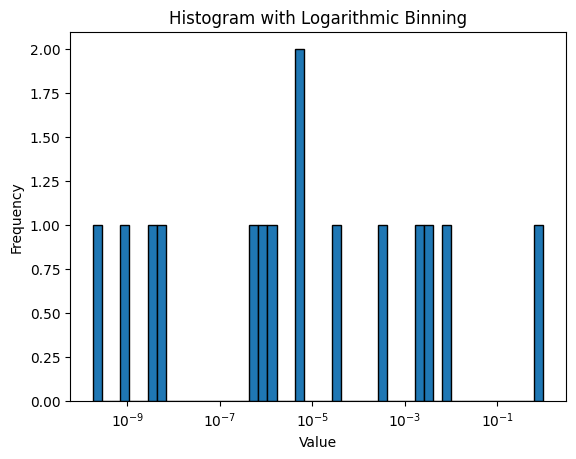

In [37]:
data = np.array(c_sen)
data = data[data > 1e-10]
bins = np.logspace(np.log10(data.min()),
                   np.log10(data.max()),
                   50)

# Plot histogram
plt.hist(data, bins=bins, edgecolor='black')

# Log scale for x-axis (important)
plt.xscale('log')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram with Logarithmic Binning')
plt.show()

In [15]:
HQ = jordan_wigner(H)
for op in sym_ops_all[:14]:
    print(op)
    print(uni_grading([op], HQ))
    probs = find_overlaps([op], fci, 14)
    print(probs, entropy(probs))



1.0 [Z8 Z9]
0.0
[np.complex128(0.999999999999996+0j), np.complex128(1.0471858146218168e-26+0j)] (5.7661677077705765e-15+0j)
1.0 [Z4 Z5 Z12 Z13]
0.0
[np.complex128(0.999999999999996+0j), np.complex128(2.432693728111516e-27+0j)] (5.766167707081891e-15+0j)
1.0 [Z1 Z3 Z5 Z7 Z9 Z11 Z13]
0.0
[np.complex128(5.3279609881241306e-27+0j), np.complex128(0.999999999999996+0j)] (5.766167707331833e-15+0j)
1.0 [Z0 Z2 Z5 Z6 Z9 Z10 Z13]
0.0
[np.complex128(7.725180241889396e-27+0j), np.complex128(0.999999999999996+0j)] (5.766167707536918e-15+0j)
1.0 [Z13]
6.802891360112045
[np.complex128(0.9867277187435428+0j), np.complex128(0.013272281256453161+0j)] (0.10177873169697495+0j)
1.0 [Z12]
6.802891360112046
[np.complex128(0.9867277187435425+0j), np.complex128(0.01327228125645348+0j)] (0.1017787316969771+0j)
1.0 [Z11]
8.755568499484163
[np.complex128(0.9867795258835833+0j), np.complex128(0.013220474116412678+0j)] (0.10145654200378104+0j)
1.0 [Z10]
8.755568499484163
[np.complex128(0.9867795258835835+0j), np.com

In [ ]:
#useful functions
from openfermion import commutator
def find_meas_cost(H, symmetries, gs, tol):

    #find significant coeffs and wfn parts

    #find fragments of reduced Hamiltonians and their variances

    #find opt cost

    return

def is_commuting(A, B, tol=1e-5):
    return np.sum(np.abs(commutator(A, B).terms.values())) < tol

def find_clifford_to_Z0(S: QubitOperator):
    """
    Clifford that transforms S to Z0
    
    """
    Z0 = QubitOperator('Z0', 1.0)

    if not is_commuting(S, Z0):
        return (Z0 + S)/np.sqrt(2)

    else:
        #find common anti-commuting operator
        return

In [17]:
sym_ops =  sym_ops_all[:n_qubits//2]
projs = construct_projectors(sym_ops)
projs_sparse = [get_sparse_operator(proj, n_qubits) for proj in projs]
Hs = get_sparse_operator(jordan_wigner(H), n_qubits)
min([get_ground_state(proj @ Hs @ proj)[0] for proj in projs_sparse])

np.float64(-3.1418504961498717)

In [19]:
sym_ops

[1.0 [Z2 Z3 Z6 Z7 Z10 Z11],
 1.0 [Z1 Z3 Z5 Z7 Z9 Z11],
 1.0 [Z0 Z3 Z4 Z7 Z8 Z11],
 1.0 [Z6 Z7 Z8 Z9 Z10 Z11],
 1.0 [Z7 Z9 Z11],
 1.0 [Z4 Z5 Z8 Z9 Z10 Z11]]

In [18]:
sen_syms = [QubitOperator('Z{} Z{}'.format(2*i, 2*i+1), 1) for i in range(n_H)]
projs = construct_projectors(sen_syms)
projs_sparse = [get_sparse_operator(proj, n_qubits) for proj in projs]
Hs = get_sparse_operator(jordan_wigner(H), n_qubits)
min([get_ground_state(proj @ Hs @ proj)[0] for proj in projs_sparse])

np.float64(-3.170861321033622)

In [10]:
projs = construct_projectors(sym_ops_all[:4])
l1_hct, c = find_overlaps_l1(sym_ops_all[:4], fci, n_qubits)
print(l1_hct)
min([get_ground_state(get_sparse_operator(proj * jordan_wigner(H) * proj, n_qubits))[0] for proj in projs])

1.0120323563836673


np.float64(-2.1662150951072685)

In [ ]:
sen_syms = [QubitOperator('Z{} Z{}'.format(2*i, 2*i+1), 1) for i in range(n_H)]
l1_sen, c2 = find_overlaps_l1(sen_syms, fci, n_qubits) #actual goodness
uni_sen = uni_grading(sen_syms, jordan_wigner(H)) #proxy
state_sen = state_grading(sen_syms, jordan_wigner(H), fci, n_qubits) #better proxy
#to check of proxy is positively correlated to actual goodness of symmetries

#doesn't seem very well correlated (test with sym_ops_all[3:7])

print(uni_sen, state_sen, l1_sen)
#np.sort(c2)

11.59420492739591 (1.0572039413412453-1.0408340855860843e-17j) 1.1452346603817158
